In [ ]:
# === [TFM_newcodes] redireccion de figuras a la carpeta ./figures/ ===
# Celda anadida automaticamente: cualquier figura guardada con un nombre
# de fichero simple (sin carpeta) se guarda dentro de ./figures/.
# Las rutas que ya incluyen una carpeta (p.ej. 'figures/...') se respetan.
import os as _os
import matplotlib.pyplot as _plt
from matplotlib.figure import Figure as _Figure
_os.makedirs('figures', exist_ok=True)
def _fig_redirect(fname):
    try:
        p = _os.fspath(fname)
    except TypeError:
        return fname  # objeto tipo fichero/buffer: no tocar
    if _os.path.dirname(p) == '':
        p = _os.path.join('figures', p)
    d = _os.path.dirname(p)
    if d:
        _os.makedirs(d, exist_ok=True)
    return p
if not getattr(_plt.savefig, '_tfm_patched', False):
    _orig_plt_savefig = _plt.savefig
    _orig_fig_savefig = _Figure.savefig
    def _plt_savefig(fname, *a, **k):
        return _orig_plt_savefig(_fig_redirect(fname), *a, **k)
    _plt_savefig._tfm_patched = True
    def _fig_savefig(self, fname, *a, **k):
        return _orig_fig_savefig(self, _fig_redirect(fname), *a, **k)
    _plt.savefig = _plt_savefig
    _Figure.savefig = _fig_savefig
savefig = _plt.savefig  # por si se usa savefig(...) directamente


# Temporal Distribution by Rescaling

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [3]:
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.

## Rescaling

In [4]:
# Check data structure
print(df.shape)
print(df.columns)
df.head()

(18064, 17)
Index(['id', 'date', 'message', 'reply_to_msg_id', 'views', 'forwards',
       'edit_date', 'pinned', 'post_author', 'sender_id', 'sender_username',
       'sender_name', 'has_media', 'reactions', 'subgroup', 'topic_name',
       'reply'],
      dtype='object')


,id,date,message,reply_to_msg_id,views,forwards,edit_date,pinned,post_author,sender_id,sender_username,sender_name,has_media,reactions,subgroup,topic_name,reply
0,3,2024-10-30 12:39:24+00:00,Os paso por aquí el correo,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
1,4,2024-10-30 12:40:50+00:00,LO AVISÉ EL VIERNES PASADO Y NADIE ME HIZO CAS...,NaN,46823.0,1057.0,2024-11-01T18:21:38+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 5887977931, 'username': '', 'disp...",None,Discusión general,False
2,5,2024-10-30 12:43:17+00:00,,NaN,NaN,NaN,2024-11-03T22:44:05+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 6970134793, 'username': '', 'disp...",None,Discusión general,False
3,6,2024-10-30 12:43:23+00:00,Probad si podeis,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
4,7,2024-10-30 12:46:02+00:00,Durante la tormenta al parecer sí estaba opera...,4.0,NaN,NaN,None,False,NaN,941865373,Camelocota,Víctor Conejero,False,[],Thread_4,Discusión general,True


In [5]:
# Convert date to datetime and sort by time
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Total messages: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Total messages: 18064
Date range: 2024-10-30 12:39:24+00:00 to 2025-11-10 11:06:47+00:00


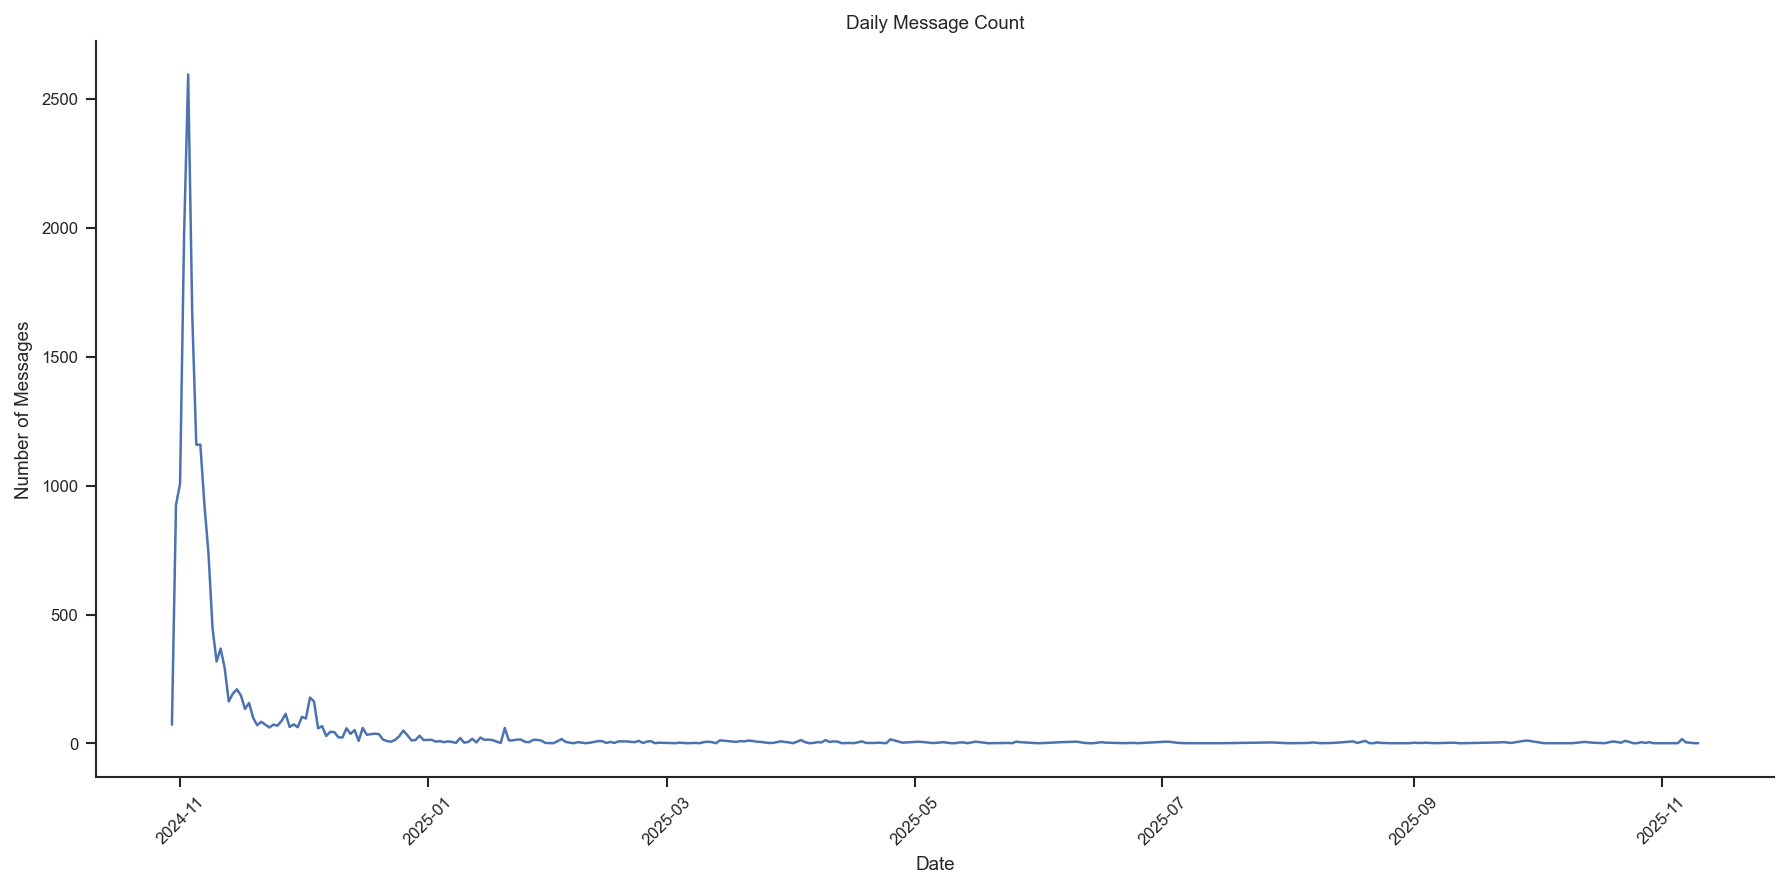

In [6]:
# Plot the distribution of messages over time (daily)
plt.figure(figsize=(12, 6))
df['date_only'] = df['date'].dt.date
daily_counts = df.groupby('date_only').size()
daily_counts.plot(kind='line')
plt.title('Daily Message Count')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of messages until Jan 1st 2025

Total messages until Jan 1st 2025: 17044
Total messages sent in total (until Nov 10th 2025): 18064
Date range: 2024-10-30 12:39:24+00:00 to 2024-12-31 22:50:08+00:00


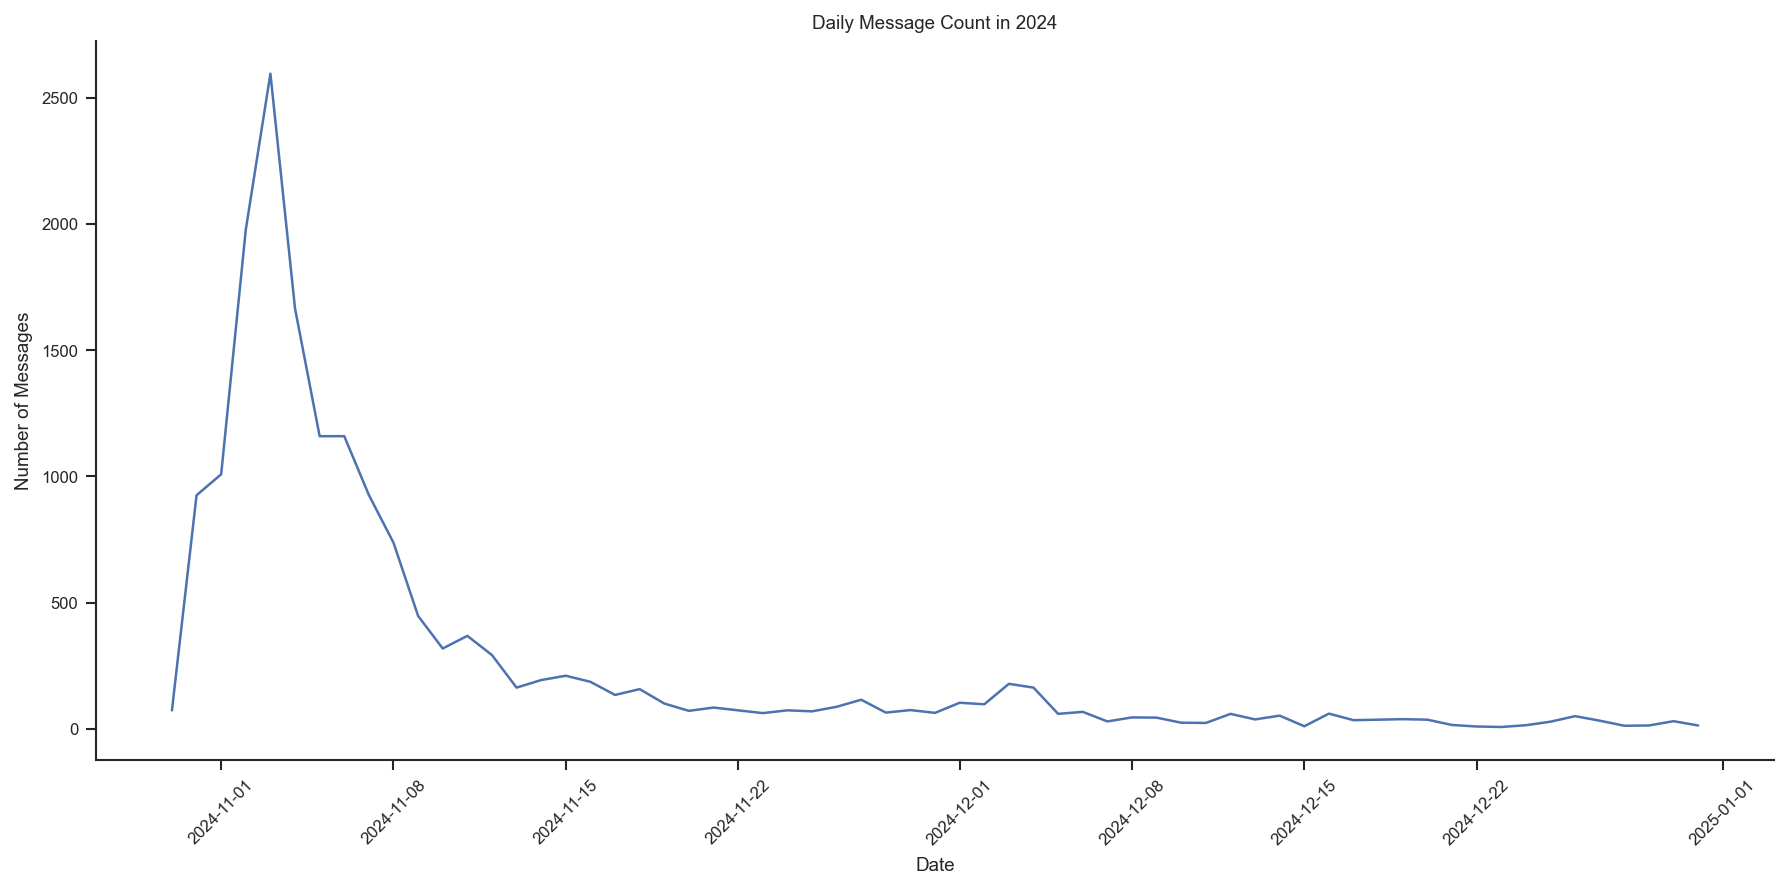

In [7]:
# Create new dataframe with messages until Jan 1st 2025
df_2024 = df[df['date'] < '2025-01-01'].copy()
print(f"Total messages until Jan 1st 2025: {len(df_2024)}")
print(f"Total messages sent in total (until Nov 10th 2025): {len(df)}")
print(f"Date range: {df_2024['date'].min()} to {df_2024['date'].max()}")

# Plot the distribution of messages over time (daily) for 2024
plt.figure(figsize=(12, 6))
df_2024['date_only'] = df_2024['date'].dt.date
daily_counts_2024 = df_2024.groupby('date_only').size()
daily_counts_2024.plot(kind='line', title='Daily Message Count in 2024')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Calculate waiting times (inter-arrival times) between consecutive messages

# Calculate time differences in seconds
df_2024['waiting_time'] = df_2024['date'].diff().dt.total_seconds()

# Remove the first NaN value and negative values (if any)
waiting_times = df_2024['waiting_time'].dropna()
waiting_times = waiting_times[waiting_times > 0]





print(f"Number of waiting times: {len(waiting_times)}")
print(f"Statistics:")
print(f"  Mean: {waiting_times.mean():.2f} seconds ({waiting_times.mean()/60:.2f} minutes)")
print(f"  Median: {waiting_times.median():.2f} seconds ({waiting_times.median()/60:.2f} minutes)")
print(f"  Min: {waiting_times.min():.2f} seconds")
print(f"  Max: {waiting_times.max():.2f} seconds ({waiting_times.max()/3600:.2f} hours)")




Number of waiting times: 16222
Statistics:
  Mean: 332.48 seconds (5.54 minutes)
  Median: 35.00 seconds (0.58 minutes)
  Min: 1.00 seconds
  Max: 64566.00 seconds (17.93 hours)


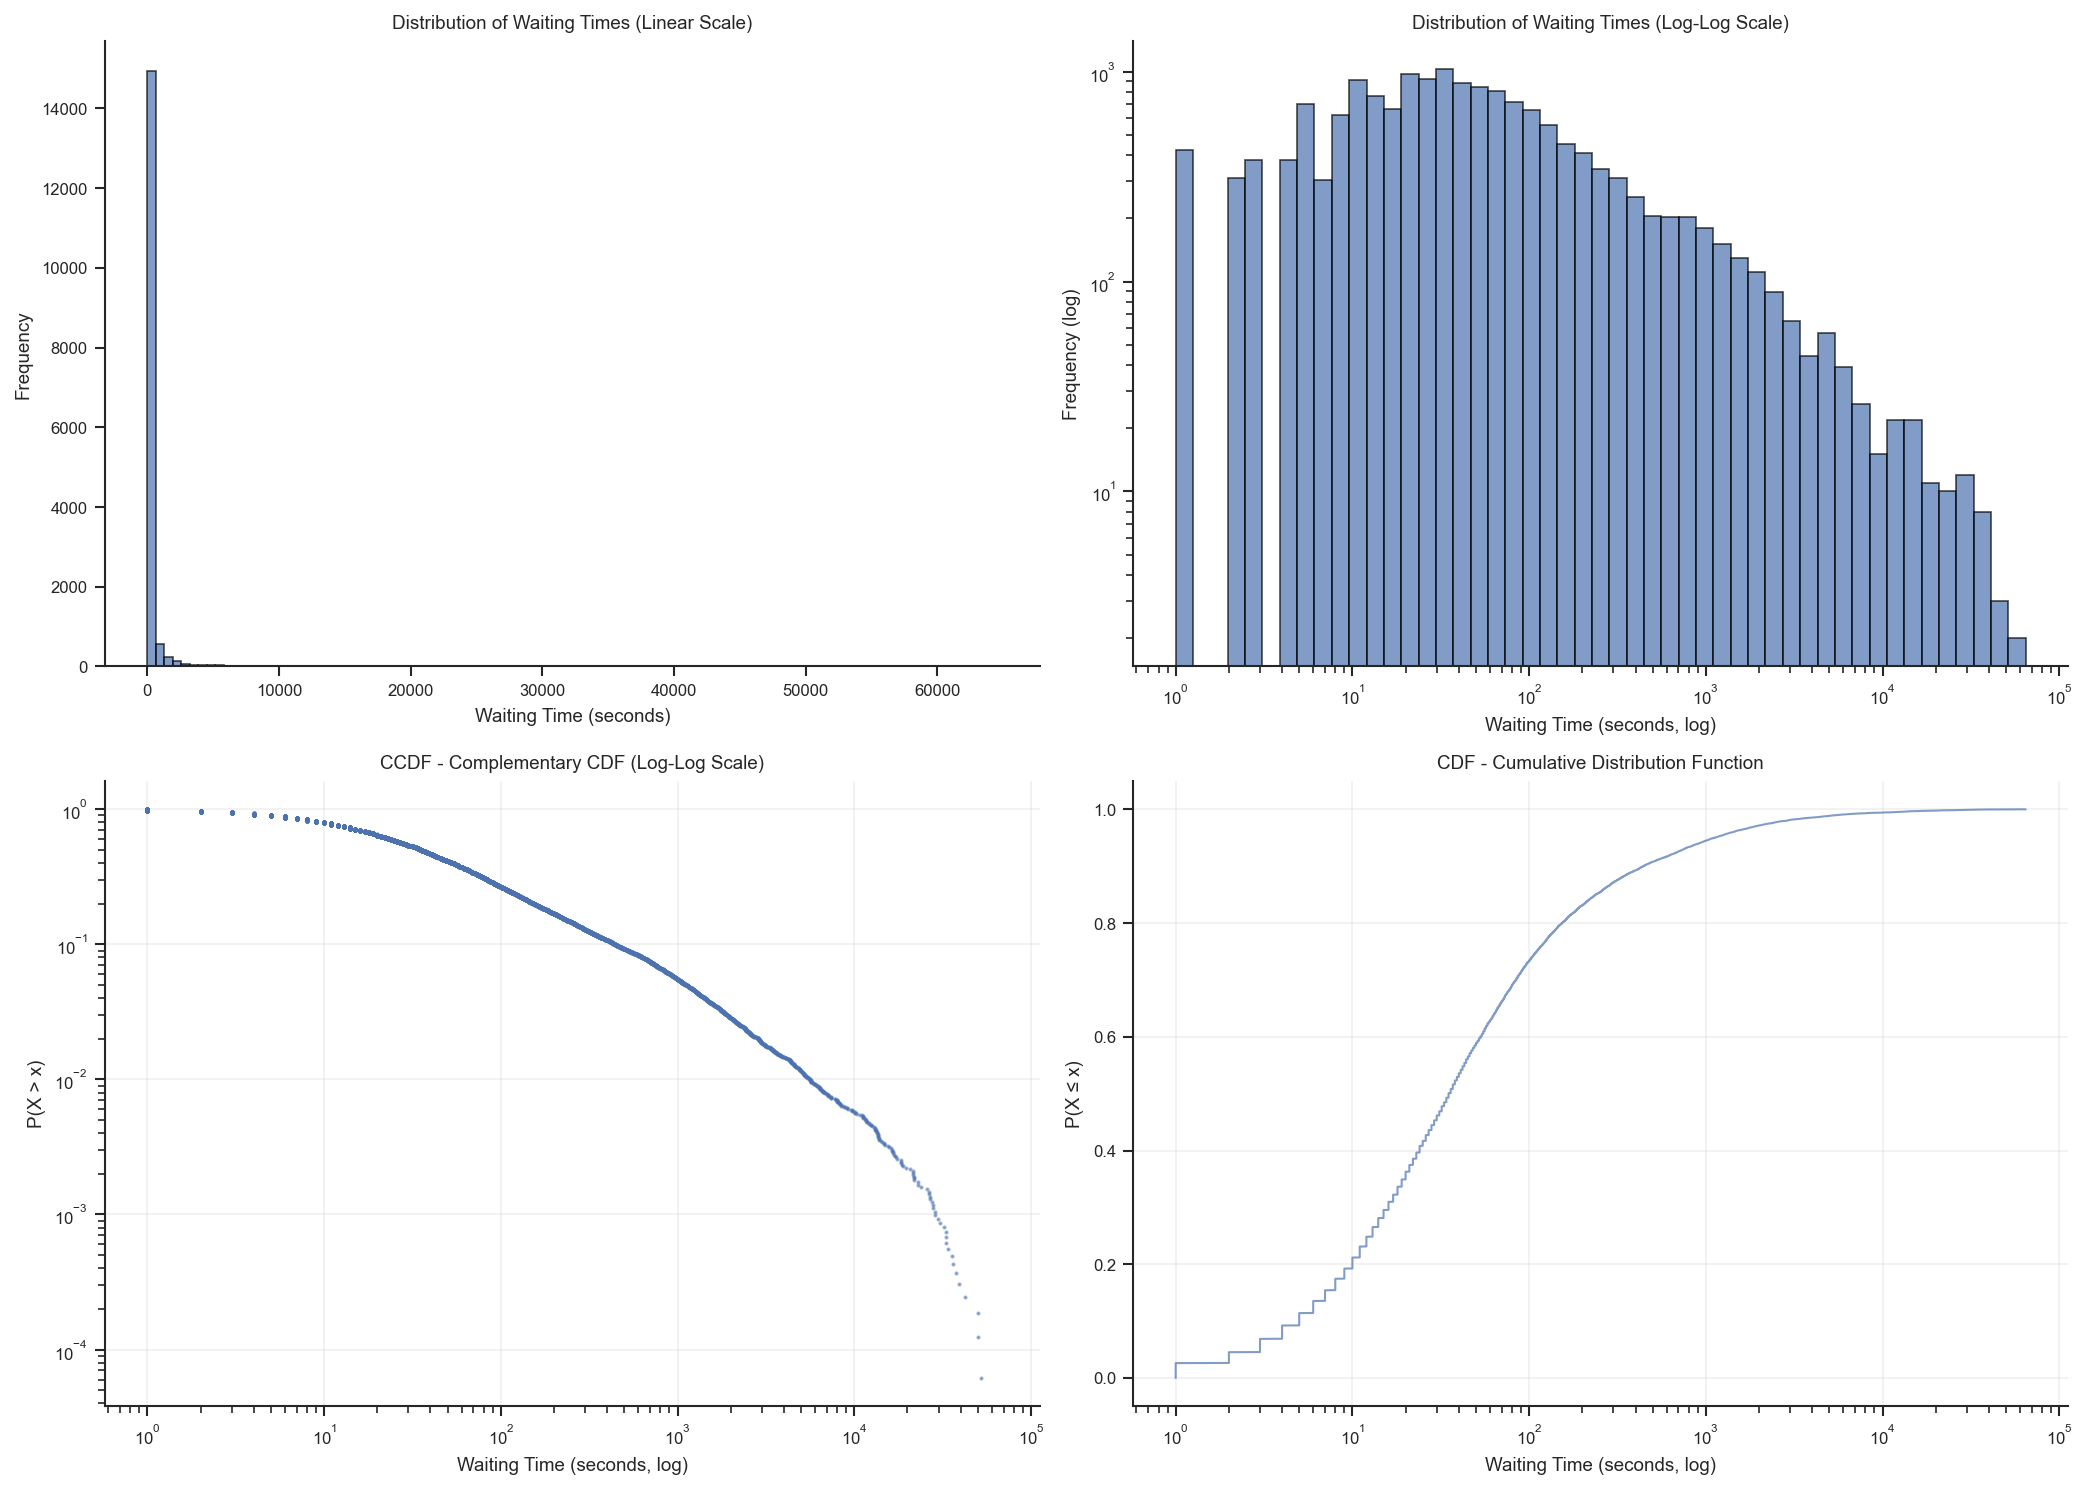

In [9]:
# Visualize the distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram on linear scale
axes[0, 0].hist(waiting_times, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Waiting Time (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Waiting Times (Linear Scale)')

# Histogram on log-log scale
axes[0, 1].hist(waiting_times, bins=np.logspace(np.log10(waiting_times.min()), 
                                                  np.log10(waiting_times.max()), 50),
                edgecolor='black', alpha=0.7)
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Waiting Time (seconds, log)')
axes[0, 1].set_ylabel('Frequency (log)')
axes[0, 1].set_title('Distribution of Waiting Times (Log-Log Scale)')

# CCDF (Complementary Cumulative Distribution Function) on log-log scale
sorted_times = np.sort(waiting_times)
ccdf = 1 - np.arange(1, len(sorted_times) + 1) / len(sorted_times)
axes[1, 0].plot(sorted_times, ccdf, 'b.', alpha=0.5, markersize=2)
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Waiting Time (seconds, log)')
axes[1, 0].set_ylabel('P(X > x)')
axes[1, 0].set_title('CCDF - Complementary CDF (Log-Log Scale)')
axes[1, 0].grid(True, alpha=0.3)

# CDF
axes[1, 1].plot(sorted_times, np.arange(1, len(sorted_times) + 1) / len(sorted_times), 
                'b-', alpha=0.7, linewidth=1)
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('Waiting Time (seconds, log)')
axes[1, 1].set_ylabel('P(X ≤ x)')
axes[1, 1].set_title('CDF - Cumulative Distribution Function')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Fit to truncated power law

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'

TRUNCATED POWER LAW FIT RESULTS
alpha: 1.6055
lambda: 0.000038
xmin: 53.0000
sigma: nan
Data points above xmin: 6535 / 16222 (40.28%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 9.4068, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 4.2504, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 22.9280, p = 0.0000
  ✓ Truncated power law is significantly better

KS distance (truncated power law): 0.0118
✓ Good fit (KS < 0.1)


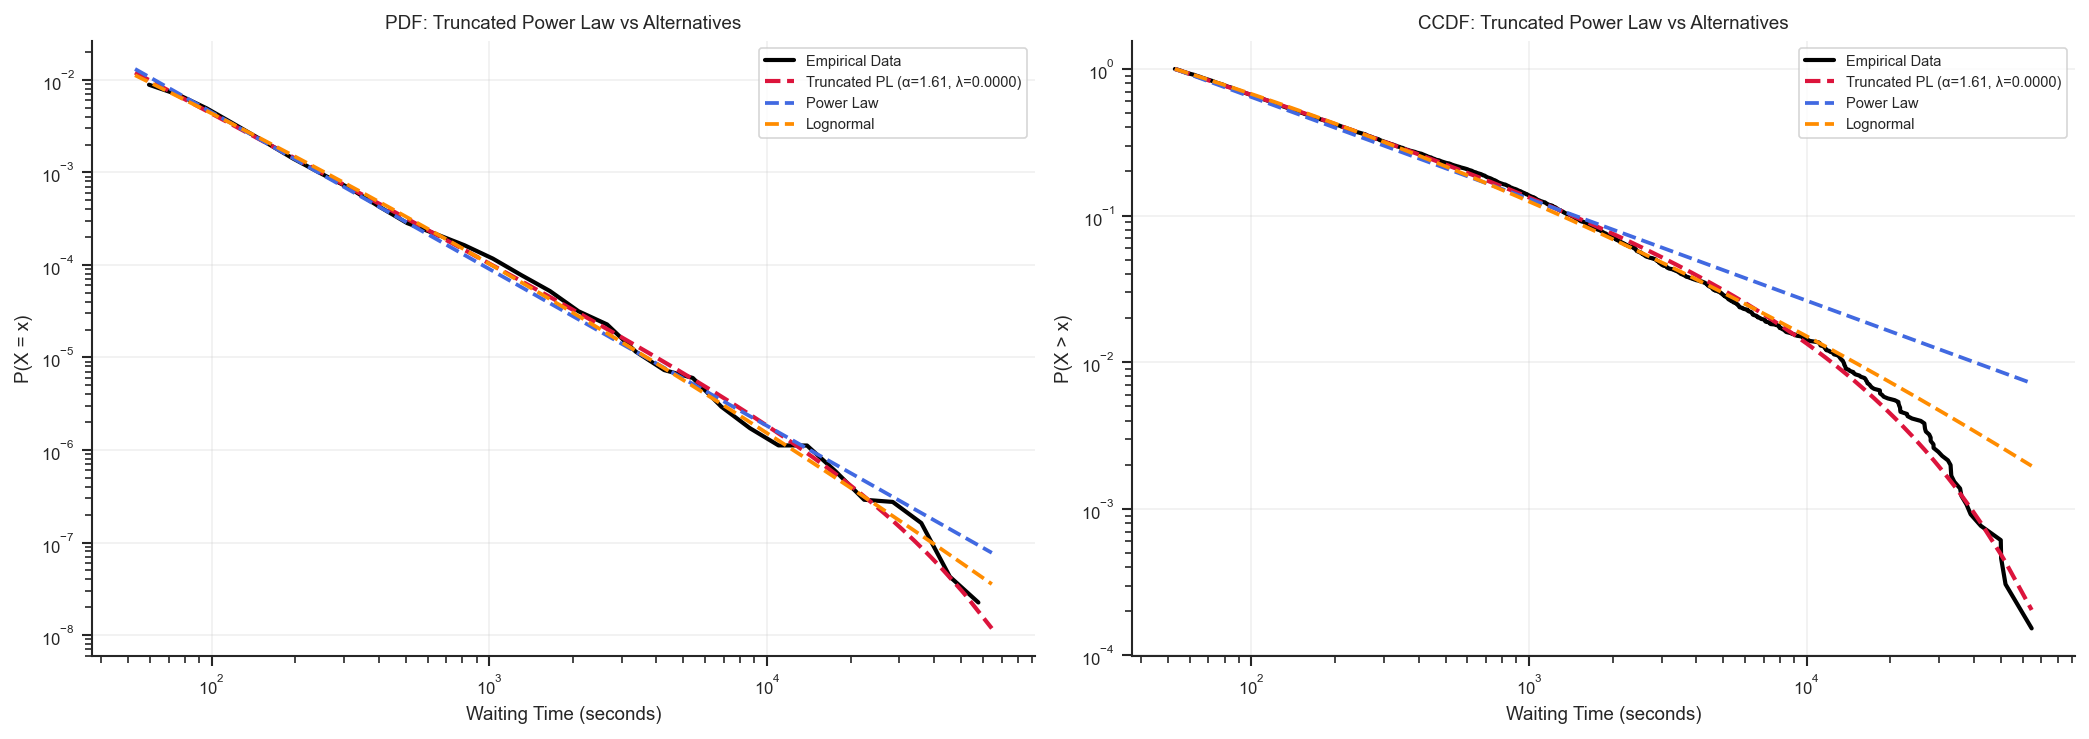

KS statistic (tail): 0.011921
KS p-value (tail): 0.308531


In [10]:
import powerlaw

# Prepare data
data_tpl = np.asarray(waiting_times.values, dtype=float)
data_tpl = data_tpl[np.isfinite(data_tpl)]
data_tpl = data_tpl[data_tpl > 0]

# Fit using powerlaw package
fit_tpl = powerlaw.Fit(data_tpl, discrete=False, verbose=False)
tpl = fit_tpl.truncated_power_law

alpha_tpl = getattr(tpl, "alpha", np.nan)
lambda_tpl = getattr(tpl, "Lambda", np.nan)
xmin_tpl = getattr(tpl, "xmin", np.nan)
sigma_tpl = getattr(tpl, "sigma", np.nan)

print("="*70)
print("TRUNCATED POWER LAW FIT RESULTS")
print("="*70)
print(f"alpha: {alpha_tpl:.4f}")
print(f"lambda: {lambda_tpl:.6f}")
print(f"xmin: {xmin_tpl:.4f}")
print(f"sigma: {sigma_tpl:.4f}")
n_tail_tpl = int(np.sum(data_tpl >= xmin_tpl))
print(f"Data points above xmin: {n_tail_tpl} / {len(data_tpl)} ({100 * n_tail_tpl / len(data_tpl):.2f}%)")

# Likelihood-ratio comparisons (positive R => first model preferred)
print("\n" + "="*70)
print("TRUNCATED POWER LAW COMPARISONS")
print("="*70)
comparisons = [
    ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
    ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
    ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
]

for d1, d2, label in comparisons:
    R, p = fit_tpl.distribution_compare(d1, d2, normalized_ratio=True)
    print(f"\n{label}:")
    print(f"  R = {R:.4f}, p = {p:.4f}")
    if p < 0.05:
        if R > 0:
            print("  ✓ Truncated power law is significantly better")
        else:
            print(f"  ✗ {d2.replace('_', ' ')} is significantly better")
    else:
        print("  ≈ No significant difference")

# Manual KS distance for truncated power law
tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
if len(tail_tpl) == 0:
    ks_tpl = float("nan")
else:
    empirical_cdf_tpl = np.arange(1, len(tail_tpl) + 1) / len(tail_tpl)
    try:
        model_cdf_tpl = tpl.cdf(tail_tpl)
    except Exception:
        model_cdf_tpl = 1 - tpl.ccdf(tail_tpl)
    ks_tpl = np.max(np.abs(empirical_cdf_tpl - model_cdf_tpl))

print("\n" + "="*70)
print(f"KS distance (truncated power law): {ks_tpl:.4f}")
if np.isnan(ks_tpl):
    print("KS could not be computed (no data >= xmin).")
elif ks_tpl < 0.1:
    print("✓ Good fit (KS < 0.1)")
elif ks_tpl < 0.15:
    print("~ Moderate fit (0.1 ≤ KS < 0.15)")
else:
    print("✗ Poor fit (KS ≥ 0.15)")
print("="*70)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fit_tpl.plot_pdf(color='black', linewidth=2, label='Empirical Data', ax=axes[0])
tpl.plot_pdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl:.2f}, λ={lambda_tpl:.4f})', ax=axes[0]
 )
fit_tpl.power_law.plot_pdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[0])
fit_tpl.lognormal.plot_pdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[0])
axes[0].set_xlabel('Waiting Time (seconds)')
axes[0].set_ylabel('P(X = x)')
axes[0].set_title('PDF: Truncated Power Law vs Alternatives')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fit_tpl.plot_ccdf(color='black', linewidth=2, label='Empirical Data', ax=axes[1])
tpl.plot_ccdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl:.2f}, λ={lambda_tpl:.4f})', ax=axes[1]
 )
fit_tpl.power_law.plot_ccdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[1])
fit_tpl.lognormal.plot_ccdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[1])
axes[1].set_xlabel('Waiting Time (seconds)')
axes[1].set_ylabel('P(X > x)')
axes[1].set_title('CCDF: Truncated Power Law vs Alternatives')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# One-off: compute KS p-value for truncated power law tail fit
from scipy import stats

tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
ks_stat_tpl, ks_p_tpl = stats.kstest(tail_tpl, tpl.cdf)
print("="*70)
print(f"KS statistic (tail): {ks_stat_tpl:.6f}")
print(f"KS p-value (tail): {ks_p_tpl:.6g}")
print("="*70)

### Time-rescaling theorem

*Put text explaining what I am doing*

In [11]:
# Filter waiting times that are >= xmin
tail_mask = waiting_times >= xmin_tpl
tail_waits = waiting_times[tail_mask]

# Compute F(w) using the model's CDF
F_vals = tpl.cdf(tail_waits)          # values in [0,1]

# Transform to τ = -ln(1-F)
tau = -np.log(1 - F_vals)

# Compute z = F(w) for uniformity checks
z_vals = F_vals

Check exponential distribution of $\tau$

/var/folders/t0/sjtcv6y97xnczv424tb3c5yc0000gn/T/ipykernel_78218/2734143170.py:16: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/pablobarquin/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


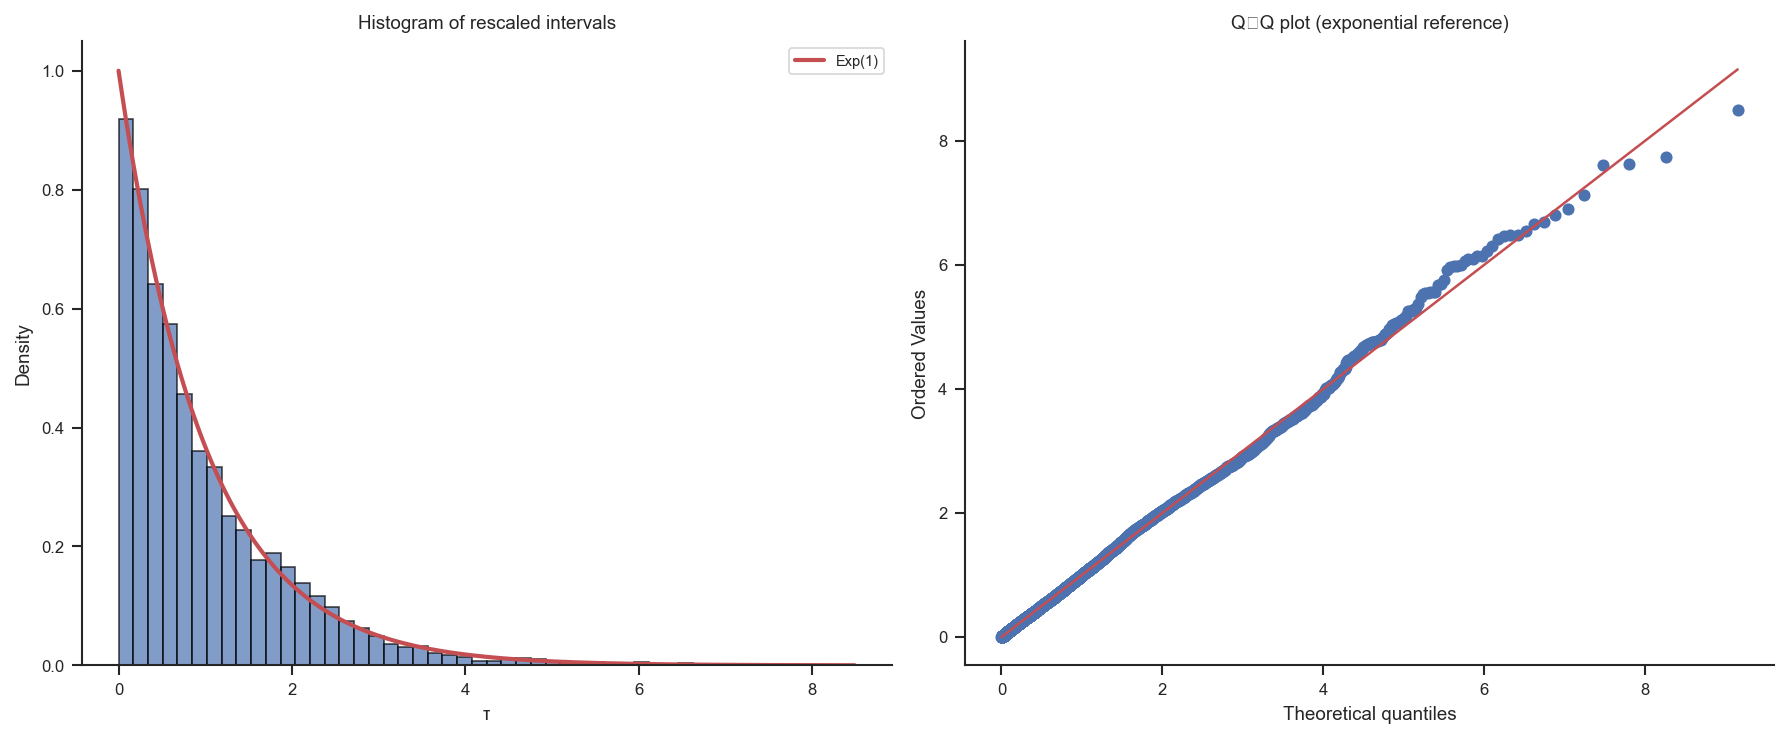

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(tau, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(0, max(tau), 200)
axes[0].plot(x, stats.expon.pdf(x, scale=1), 'r-', lw=2, label='Exp(1)')
axes[0].set_xlabel('τ')
axes[0].set_ylabel('Density')
axes[0].set_title('Histogram of rescaled intervals')
axes[0].legend()

# QQ‑plot against exponential
stats.probplot(tau, dist=stats.expon, plot=axes[1])
axes[1].set_title('Q‑Q plot (exponential reference)')

plt.tight_layout()
plt.show()

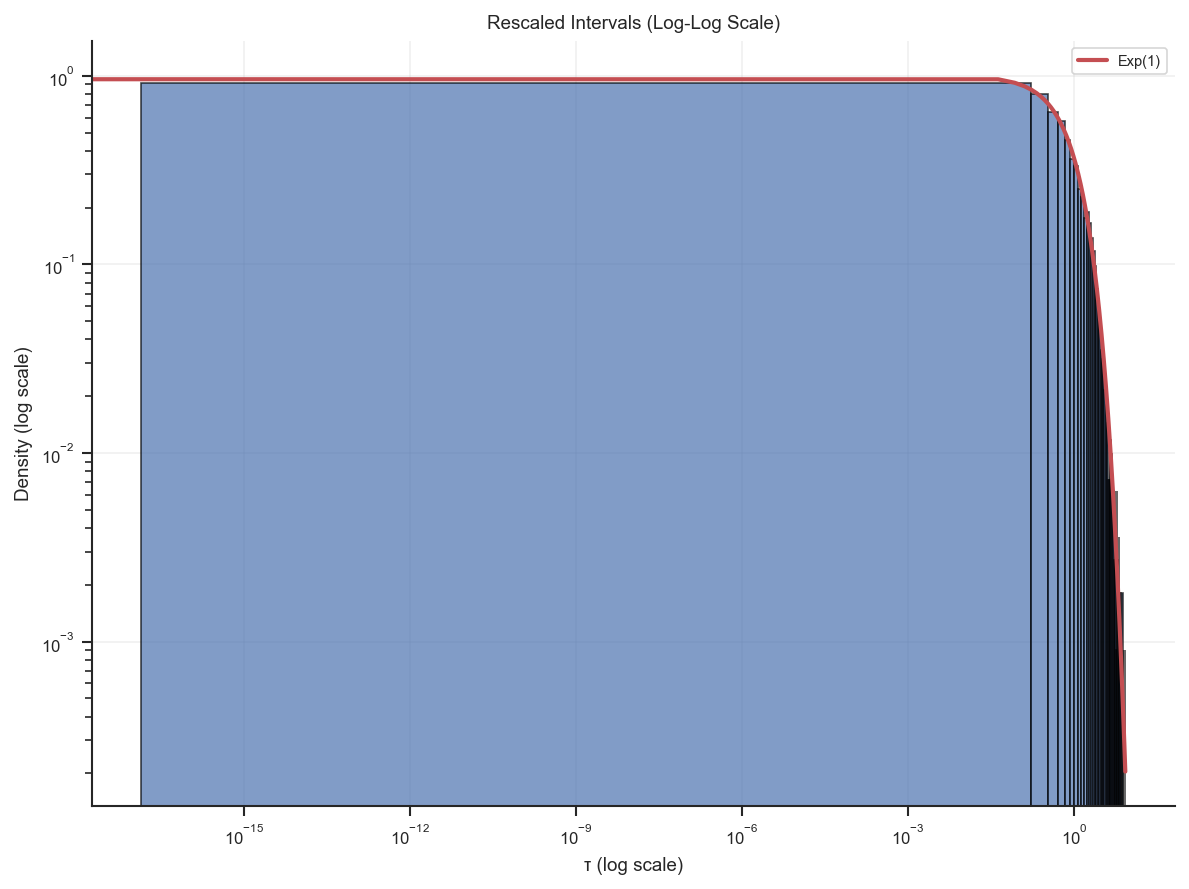

In [13]:
# Plot in log-log scale rescaled histogram
plt.figure(figsize=(8, 6))
plt.hist(tau, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(0, max(tau), 200)
plt.plot(x, stats.expon.pdf(x, scale=1), 'r-', lw=2, label='Exp(1)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('τ (log scale)')
plt.ylabel('Density (log scale)')
plt.title('Rescaled Intervals (Log-Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




In [14]:
ks_stat, ks_p = stats.kstest(tau, 'expon', args=(0, 1))
print(f"KS test for exponential(1): statistic = {ks_stat:.4f}, p = {ks_p:.4f}")

KS test for exponential(1): statistic = 0.0119, p = 0.3085


### Universal Scaling Law (from Lab 1 & P.Set A from Experimental Techniques)
Ask Emanuele if this is correct.

TRUNCATED POWER LAW FIT RESULTS (RESCALED)
alpha: 1.6055
lambda: 0.012494
xmin: 0.1594
sigma: nan


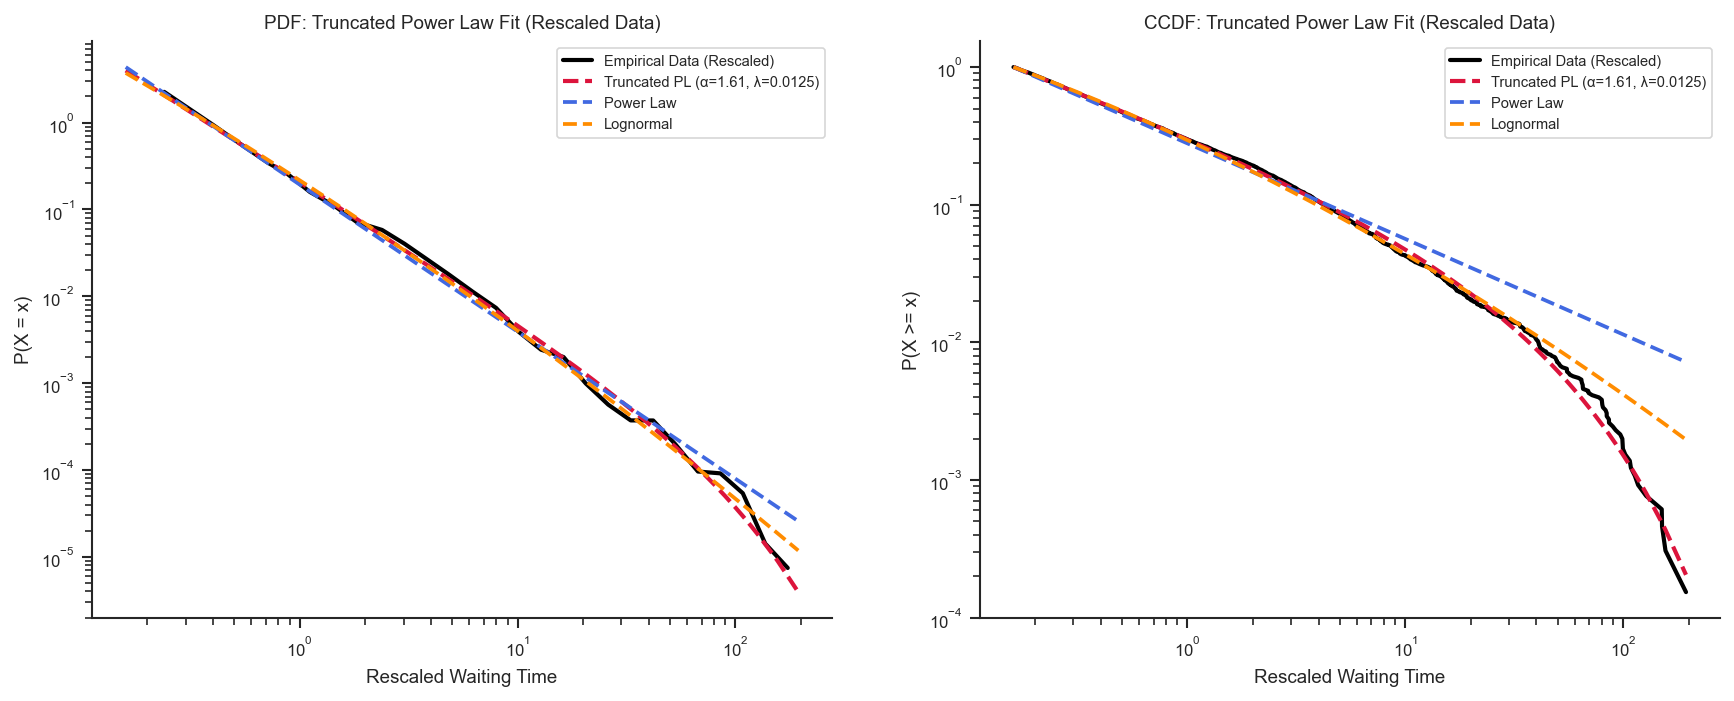

In [15]:
# Rescale the values of the waiting times using the average of them.
waiting_times_rescaled = waiting_times / waiting_times.mean()

# Fit to truncated power law again with rescaled data
data_tpl_rescaled = np.asarray(waiting_times_rescaled.values, dtype=float)
data_tpl_rescaled = data_tpl_rescaled[np.isfinite(data_tpl_rescaled)]
data_tpl_rescaled = data_tpl_rescaled[data_tpl_rescaled > 0]
fit_tpl_rescaled = powerlaw.Fit(data_tpl_rescaled, discrete=False, verbose=False)
tpl_rescaled = fit_tpl_rescaled.truncated_power_law
alpha_tpl_rescaled = getattr(tpl_rescaled, "alpha", np.nan)
lambda_tpl_rescaled = getattr(tpl_rescaled, "Lambda", np.nan)
xmin_tpl_rescaled = getattr(tpl_rescaled, "xmin", np.nan)
sigma_tpl_rescaled = getattr(tpl_rescaled, "sigma", np.nan)
print("="*70)
print("TRUNCATED POWER LAW FIT RESULTS (RESCALED)")
print("="*70)
print(f"alpha: {alpha_tpl_rescaled:.4f}")
print(f"lambda: {lambda_tpl_rescaled:.6f}")
print(f"xmin: {xmin_tpl_rescaled:.4f}")
print(f"sigma: {sigma_tpl_rescaled:.4f}")

# Plot rescaled data and fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fit_tpl_rescaled.plot_pdf(color='black', linewidth=2, label='Empirical Data (Rescaled)', ax=axes[0])
tpl_rescaled.plot_pdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl_rescaled:.2f}, λ={lambda_tpl_rescaled:.4f})', ax=axes[0]
 ) 
fit_tpl_rescaled.power_law.plot_pdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[0])
fit_tpl_rescaled.lognormal.plot_pdf(color='darkorange', linestyle='--', linewidth=
1.8, label='Lognormal', ax=axes[0])
axes[0].set_xlabel('Rescaled Waiting Time')
axes[0].set_ylabel('P(X = x)')
axes[0].set_title('PDF: Truncated Power Law Fit (Rescaled Data)')
axes[0].legend()
fit_tpl_rescaled.plot_ccdf(color='black', linewidth=2, label='Empirical Data (Rescaled)', ax=axes[1])
tpl_rescaled.plot_ccdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl_rescaled:.2f}, λ={lambda_tpl_rescaled:.4f})', ax=axes[1]
 ) 
fit_tpl_rescaled.power_law.plot_ccdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[1])
fit_tpl_rescaled.lognormal.plot_ccdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[1])
axes[1].set_xlabel('Rescaled Waiting Time')
axes[1].set_ylabel('P(X >= x)')
axes[1].set_title('CCDF: Truncated Power Law Fit (Rescaled Data)')
axes[1].legend()


I cannot see the difference, ask Emanuele about it.

## Rescaling by channel

In [16]:
# Check the names of the channels.
print(df_2024['topic_name'].unique()) 

['Discusión general' 'Bienvenid@s a la Red de Voluntari@s (leed primero)'
 'Transporte de personas a Comunidad Valenciana'
 'Grupos de Acción Voluntarios en Terreno' 'Asistencia Jurídica/Seguros'
 'Asistencia Técnica y Maquinaria (mecánica, fontanería, electricidad, agricola)'
 'Asistencia animales compañia y otros'
 'Asistencia Informática/Soporte EAT'
 'Logística Interna Valencia(puntos de recepción)' 'Ayuda de Empresas'
 'Investigación Ciudadana: Responsabilidades Políticas'
 'Asistencia a Voluntarios (Comida y Acogida))'
 'Asis. Grupos Vulnerables (Maternidad , Infancia, Mayores, etc)'
 'Material Video/Fotográfico' 'Webs Esenciales'
 'Mensajes de Ayuda (Ofrezco/Necesito)'
 'Voluntarios de fuera de Valencia (Madrid, Cataluña, Alicante, Castellón)'
 'Viviendas Edificación , Muebles y Acondicionamiento']


In [17]:
# Retrieve the data from the different channels
waiting_times_general = df_2024[df_2024['topic_name'] == 'Discusión general']['waiting_time']
waiting_times_bienvenidos = df_2024[df_2024['topic_name'] == 'Bienvenid@s a la Red de Voluntari@s (leed primero)']['waiting_time']
waiting_times_tranporte = df_2024[df_2024['topic_name'] == 'Transporte de personas a Comunidad Valenciana']['waiting_time']
waiting_times_grupos_accion = df_2024[df_2024['topic_name'] == 'Grupos de Acción Voluntarios en Terreno']['waiting_time']
waiting_times_juridica = df_2024[df_2024['topic_name'] == 'Asistencia Jurídica/Seguros']['waiting_time']
waiting_times_tecnica = df_2024[df_2024['topic_name'] == 'Asistencia Técnica y Maquinaria (mecánica, fontanería, electricidad, agricola)']['waiting_time']
waiting_times_animales = df_2024[df_2024['topic_name'] == 'Asistencia animales compañia y otros']['waiting_time']
waiting_times_informatica = df_2024[df_2024['topic_name'] == 'Asistencia Informática/Soporte EAT']['waiting_time']
waiting_times_logistica = df_2024[df_2024['topic_name'] == 'Logística Interna Valencia(puntos de recepción)']['waiting_time']
waiting_times_ayudaempresas = df_2024[df_2024['topic_name'] == 'Ayuda de Empresas']['waiting_time']
waiting_times_investigacion = df_2024[df_2024['topic_name'] == 'Investigación Ciudadana: Responsabilidades Políticas']['waiting_time']
waiting_times_asistencia_voluntarios = df_2024[df_2024['topic_name'] == 'Asistencia a Voluntarios (Comida y Acogida))']['waiting_time']
waiting_times_asistencia_vulnerables = df_2024[df_2024['topic_name'] == 'Asis. Grupos Vulnerables (Maternidad , Infancia, Mayores, etc)']['waiting_time']
waiting_times_material = df_2024[df_2024['topic_name'] == 'Material Video/Fotográfico']['waiting_time']
waiting_times_webs = df_2024[df_2024['topic_name'] == 'Webs Esenciales']['waiting_time']
waiting_times_mensajes_ayuda = df_2024[df_2024['topic_name'] == 'Mensajes de Ayuda (Ofrezco/Necesito)']['waiting_time']
waiting_times_voluntarios_fuera = df_2024[df_2024['topic_name'] == 'Voluntarios de fuera de Valencia (Madrid, Cataluña, Alicante, Castellón)']['waiting_time']
waiting_times_viviendas = df_2024[df_2024['topic_name'] == 'Viviendas Edificación , Muebles y Acondicionamiento']['waiting_time']




In [18]:
# Define a consistent color palette for all channels
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Using tab20 colormap which provides 20 distinct colors
tab20 = cm.get_cmap('tab20')
channel_colors = {
    'General': tab20(0),
    'Bienvenidos': tab20(1),
    'Transporte': tab20(2),
    'Grupos de Acción': tab20(3),
    'Jurídica': tab20(4),
    'Técnica': tab20(5),
    'Animales': tab20(6),
    'Informática': tab20(7),
    'Logística': tab20(8),
    'Ayuda a Empresas': tab20(9),
    'Investigación': tab20(10),
    'Asistencia a Voluntarios': tab20(11),
    'Asistencia a Grupos Vulnerables': tab20(12),
    'Material': tab20(13),
    'Webs': tab20(14),
    'Mensajes de Ayuda': tab20(15),
    'Voluntarios de Fuera': tab20(16),
    'Viviendas': tab20(17)
}

print("Color palette created with 18 distinct colors for all channels")

Color palette created with 18 distinct colors for all channels


/var/folders/t0/sjtcv6y97xnczv424tb3c5yc0000gn/T/ipykernel_78218/3019095795.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = cm.get_cmap('tab20')


### Time-Rescaling theorem by channel

In [19]:
# Obtain the truncated power law fit for the waiting times of the different channels
poll_waiting_times = {
    'General': waiting_times_general,
    'Bienvenidos': waiting_times_bienvenidos,
    'Transporte': waiting_times_tranporte,
    'Grupos de Acción': waiting_times_grupos_accion,
    'Jurídica': waiting_times_juridica,
    'Técnica': waiting_times_tecnica,
    'Animales': waiting_times_animales,
    'Informática': waiting_times_informatica,
    'Logística': waiting_times_logistica,
    'Ayuda a Empresas': waiting_times_ayudaempresas,
    'Investigación': waiting_times_investigacion,
    'Asistencia a Voluntarios': waiting_times_asistencia_voluntarios,
    'Asistencia a Grupos Vulnerables': waiting_times_asistencia_vulnerables,
    'Material': waiting_times_material,
    'Webs': waiting_times_webs,
    'Mensajes de Ayuda': waiting_times_mensajes_ayuda,
    'Voluntarios de Fuera': waiting_times_voluntarios_fuera,
    'Viviendas': waiting_times_viviendas
}
results = {}
for channel, waits in poll_waiting_times.items():
    data = np.asarray(waits.values, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]
    if len(data) < 100:
        print(f"Skipping {channel} (not enough data points)")
        continue
    fit = powerlaw.Fit(data, discrete=False, verbose=False)
    tpl = fit.truncated_power_law
    results[channel] = {
        'alpha': getattr(tpl, "alpha", np.nan),
        'lambda': getattr(tpl, "Lambda", np.nan),
        'xmin': getattr(tpl, "xmin", np.nan),
        'sigma': getattr(tpl, "sigma", np.nan),
        'n_tail': int(np.sum(data >= getattr(tpl, "xmin", np.nan))),
        'n_total': len(data)
    }
    print(f"Finished fitting {channel} (n={len(data)})")
    print(f"  alpha: {results[channel]['alpha']:.4f}, lambda: {results[channel]['lambda']:.6f}, xmin: {results[channel]['xmin']:.4f}, sigma: {results[channel]['sigma']:.4f}")





Finished fitting General (n=247)
  alpha: 1.5940, lambda: 0.000041, xmin: 31.0000, sigma: nan
Finished fitting Bienvenidos (n=2615)
  alpha: 2.0788, lambda: 0.000015, xmin: 72.0000, sigma: nan
Finished fitting Transporte (n=1974)
  alpha: 1.9051, lambda: 0.000009, xmin: 541.0000, sigma: nan
Finished fitting Grupos de Acción (n=926)
  alpha: 1.8179, lambda: 0.000244, xmin: 32.0000, sigma: nan


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

Finished fitting Jurídica (n=733)
  alpha: 1.4687, lambda: 0.000037, xmin: 81.0000, sigma: nan


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings

Finished fitting Técnica (n=450)
  alpha: 1.6907, lambda: 0.000040, xmin: 557.0000, sigma: nan
Finished fitting Animales (n=874)
  alpha: 1.9231, lambda: 0.000036, xmin: 1114.0000, sigma: nan
Finished fitting Informática (n=1914)
  alpha: 2.1893, lambda: 0.000000, xmin: 42.0000, sigma: nan
Finished fitting Logística (n=1188)
  alpha: 1.5041, lambda: 0.000035, xmin: 64.0000, sigma: nan
Finished fitting Ayuda a Empresas (n=246)
  alpha: 1.4668, lambda: 0.000093, xmin: 44.0000, sigma: nan


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


Finished fitting Investigación (n=2625)
  alpha: 1.6858, lambda: 0.000034, xmin: 54.0000, sigma: nan
Finished fitting Asistencia a Voluntarios (n=1128)
  alpha: 1.8890, lambda: 0.000039, xmin: 89.0000, sigma: nan
Finished fitting Asistencia a Grupos Vulnerables (n=137)
  alpha: 1.5207, lambda: 0.000833, xmin: 42.0000, sigma: nan
Finished fitting Material (n=881)
  alpha: 1.8225, lambda: 0.000020, xmin: 1040.0000, sigma: nan
Skipping Webs (not enough data points)
Skipping Mensajes de Ayuda (not enough data points)
Skipping Voluntarios de Fuera (not enough data points)
Finished fitting Viviendas (n=265)
  alpha: 1.9135, lambda: 0.000015, xmin: 1587.0000, sigma: nan


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

Skipping Webs: not enough data (n=12)
Skipping Mensajes de Ayuda: not enough data (n=3)
Skipping Voluntarios de Fuera: not enough data (n=4)
Time-rescaling summary (higher p and lower KS are better):


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

,channel,n_tail,alpha,lambda,xmin,"KS_U(0,1)","p_U(0,1)",KS_Exp(1),p_Exp(1)
0,General,150,1.594042,4.089650e-05,31.0,0.034610,0.991150,0.034610,0.991150
1,Material,123,1.822508,2.029301e-05,1040.0,0.038413,0.990310,0.038413,0.990310
2,Asistencia a Grupos Vulnerables,76,1.520711,8.327498e-04,42.0,0.050374,0.985291,0.050374,0.985291
3,Asistencia a Voluntarios,287,1.888996,3.905965e-05,89.0,0.027367,0.978660,0.027367,0.978660
4,Viviendas,63,1.913454,1.475964e-05,1587.0,0.066232,0.927890,0.066232,0.927890
5,Bienvenidos,690,2.078786,1.462642e-05,72.0,0.022834,0.856229,0.022834,0.856229
6,Logística,538,1.504092,3.523030e-05,64.0,0.027144,0.812438,0.027144,0.812438
7,Investigación,1063,1.685818,3.406476e-05,54.0,0.019383,0.811874,0.019383,0.811874
8,Grupos de Acción,457,1.817940,2.443061e-04,32.0,0.029868,0.798042,0.029868,0.798042
9,Animales,62,1.923059,3.622103e-05,1114.0,0.080497,0.786536,0.080497,0.786536


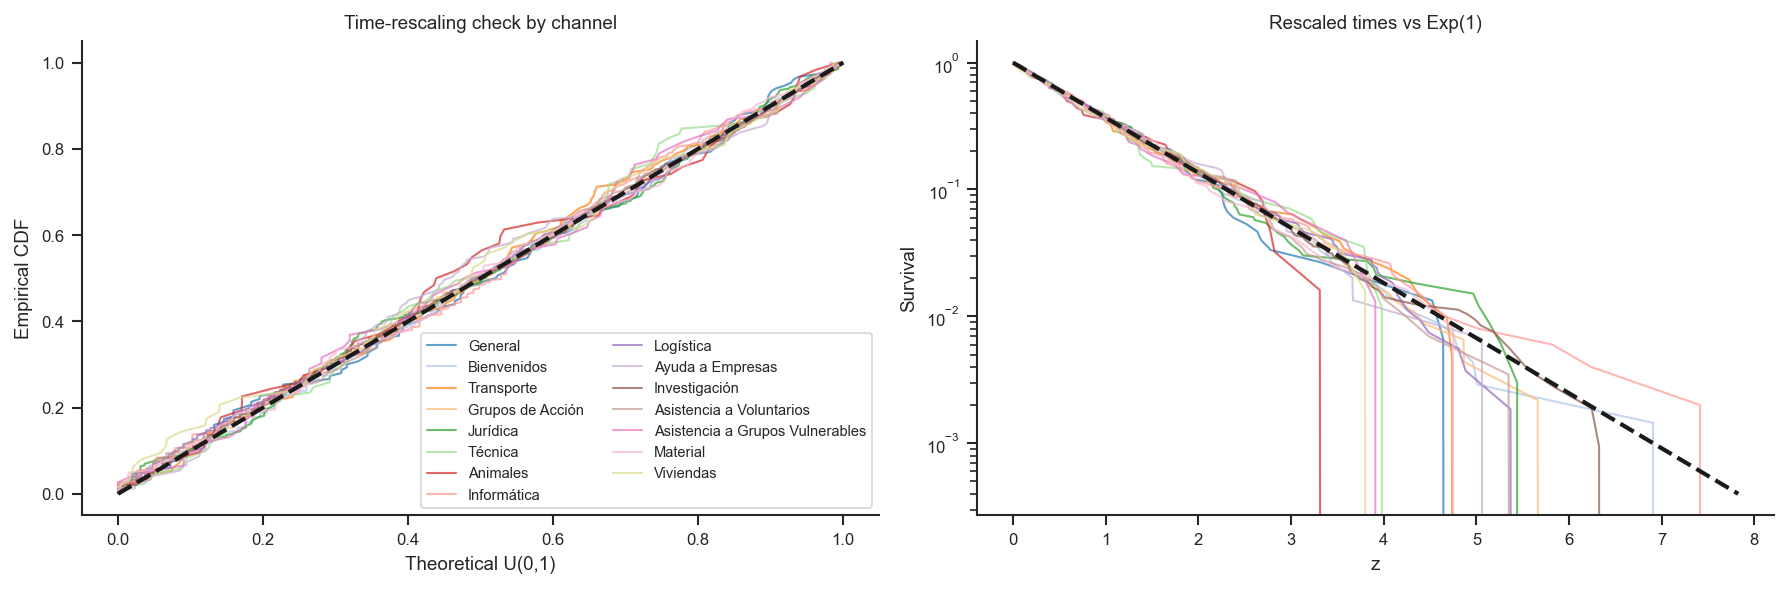

In [20]:
# Apply Time Rescaling Theorem to the waiting times of the different channels
from scipy.stats import kstest

# Containers
rescaling_results = {}
rescaling_summary_rows = []

for channel, waits in poll_waiting_times.items():
    tau = np.asarray(waits.values, dtype=float)
    tau = tau[np.isfinite(tau)]
    tau = tau[tau > 0]

    if tau.size < 100:
        print(f"Skipping {channel}: not enough data (n={tau.size})")
        continue

    # Fit TPL for this channel (same model used in previous cells)
    fit_ch = powerlaw.Fit(tau, discrete=False, verbose=False)
    tpl_ch = fit_ch.truncated_power_law
    xmin_ch = float(getattr(tpl_ch, "xmin", np.nan))

    # The theorem check is applied on the fitted tail
    tau_tail = tau[tau >= xmin_ch]
    if tau_tail.size < 30:
        print(f"Skipping {channel}: not enough tail data (n_tail={tau_tail.size})")
        continue

    # Probability integral transform: U = F(tau) should be Uniform(0,1)
    # Then z = -log(1-U) should be Exp(1)
    u = np.asarray(tpl_ch.cdf(tau_tail), dtype=float)
    u = np.clip(u, 1e-12, 1 - 1e-12)
    z = -np.log(1.0 - u)

    ks_stat_u, ks_p_u = kstest(u, "uniform")
    ks_stat_z, ks_p_z = kstest(z, "expon")

    rescaling_results[channel] = {
        "u": u,
        "z": z,
        "ks_stat_uniform": float(ks_stat_u),
        "ks_p_uniform": float(ks_p_u),
        "ks_stat_exp1": float(ks_stat_z),
        "ks_p_exp1": float(ks_p_z),
        "n_tail": int(tau_tail.size),
        "alpha": float(getattr(tpl_ch, "alpha", np.nan)),
        "lambda": float(getattr(tpl_ch, "Lambda", np.nan)),
        "xmin": xmin_ch,
    }

    rescaling_summary_rows.append(
        {
            "channel": channel,
            "n_tail": int(tau_tail.size),
            "alpha": float(getattr(tpl_ch, "alpha", np.nan)),
            "lambda": float(getattr(tpl_ch, "Lambda", np.nan)),
            "xmin": xmin_ch,
            "KS_U(0,1)": float(ks_stat_u),
            "p_U(0,1)": float(ks_p_u),
            "KS_Exp(1)": float(ks_stat_z),
            "p_Exp(1)": float(ks_p_z),
        }
    )

# Summary table (safe even if empty)
rescaling_summary = pd.DataFrame(rescaling_summary_rows)
if not rescaling_summary.empty:
    rescaling_summary = rescaling_summary.sort_values(
        ["p_U(0,1)", "KS_U(0,1)"], ascending=[False, True]
    ).reset_index(drop=True)

print("Time-rescaling summary (higher p and lower KS are better):")
display(rescaling_summary)

# Optional pooled diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for channel, out in rescaling_results.items():
    u_sorted = np.sort(out["u"])
    ecdf = np.arange(1, len(u_sorted) + 1) / len(u_sorted)
    axes[0].plot(u_sorted, ecdf, lw=1, alpha=0.7, label=channel, color=channel_colors[channel])

axes[0].plot([0, 1], [0, 1], "k--", lw=2)
axes[0].set_xlabel("Theoretical U(0,1)")
axes[0].set_ylabel("Empirical CDF")
axes[0].set_title("Time-rescaling check by channel")

for channel, out in rescaling_results.items():
    z_sorted = np.sort(out["z"])
    surv = 1.0 - np.arange(1, len(z_sorted) + 1) / len(z_sorted)
    axes[1].plot(z_sorted, surv, lw=1, alpha=0.7, label=channel, color=channel_colors[channel])

z_max = max([np.max(v["z"]) for v in rescaling_results.values()], default=8)
z_grid = np.linspace(0, z_max, 200)
axes[1].plot(z_grid, np.exp(-z_grid), "k--", lw=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("z")
axes[1].set_ylabel("Survival")
axes[1].set_title("Rescaled times vs Exp(1)")

if 0 < len(rescaling_results) <= 10:
    axes[0].legend(fontsize=8)
elif len(rescaling_results) > 10:
    axes[0].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

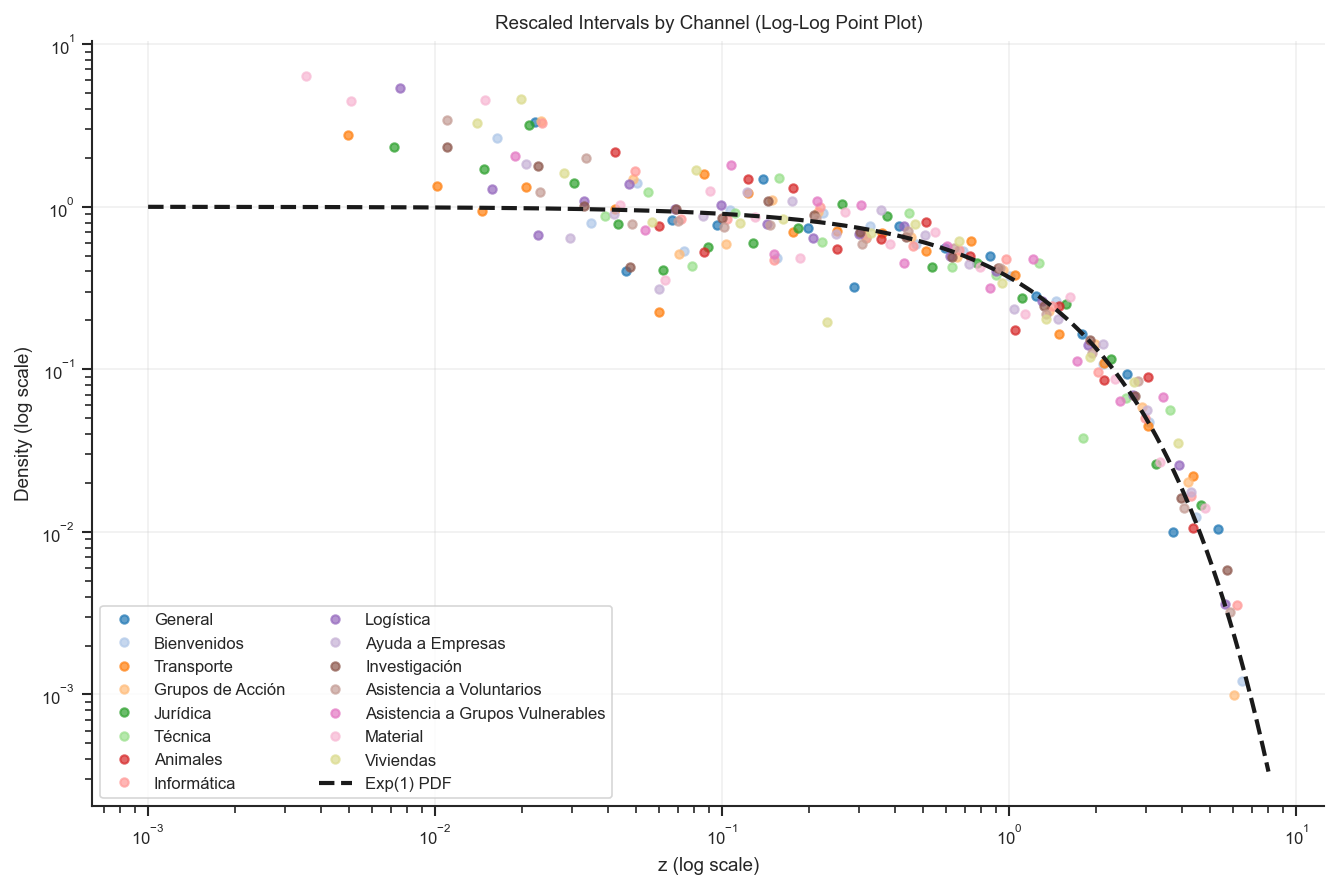

In [21]:
# Multi-channel version of the log-log rescaled-interval plot (point plot)
# Requires `rescaling_results` from the previous cell

plt.figure(figsize=(9, 6))

for channel, out in rescaling_results.items():
    z_channel = np.asarray(out["z"], dtype=float)
    z_channel = z_channel[np.isfinite(z_channel)]
    z_channel = z_channel[z_channel > 0]

    if z_channel.size < 30:
        continue

    # Log-binned empirical density (points)
    z_min = max(np.min(z_channel), 1e-3)
    z_max = np.max(z_channel)
    if z_max <= z_min:
        continue

    bins = np.logspace(np.log10(z_min), np.log10(z_max), 25)
    hist, edges = np.histogram(z_channel, bins=bins, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])

    mask = hist > 0
    plt.plot(centers[mask], hist[mask], marker='o', linestyle='none', ms=4, alpha=0.7, label=channel, color=channel_colors[channel])

# Theoretical Exp(1) density
x = np.logspace(-3, np.log10(max(8, np.max([np.max(v['z']) for v in rescaling_results.values()]))), 400)
plt.plot(x, stats.expon.pdf(x, scale=1), 'k--', lw=2, label='Exp(1) PDF')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('z (log scale)')
plt.ylabel('Density (log scale)')
plt.title('Rescaled Intervals by Channel (Log-Log Point Plot)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

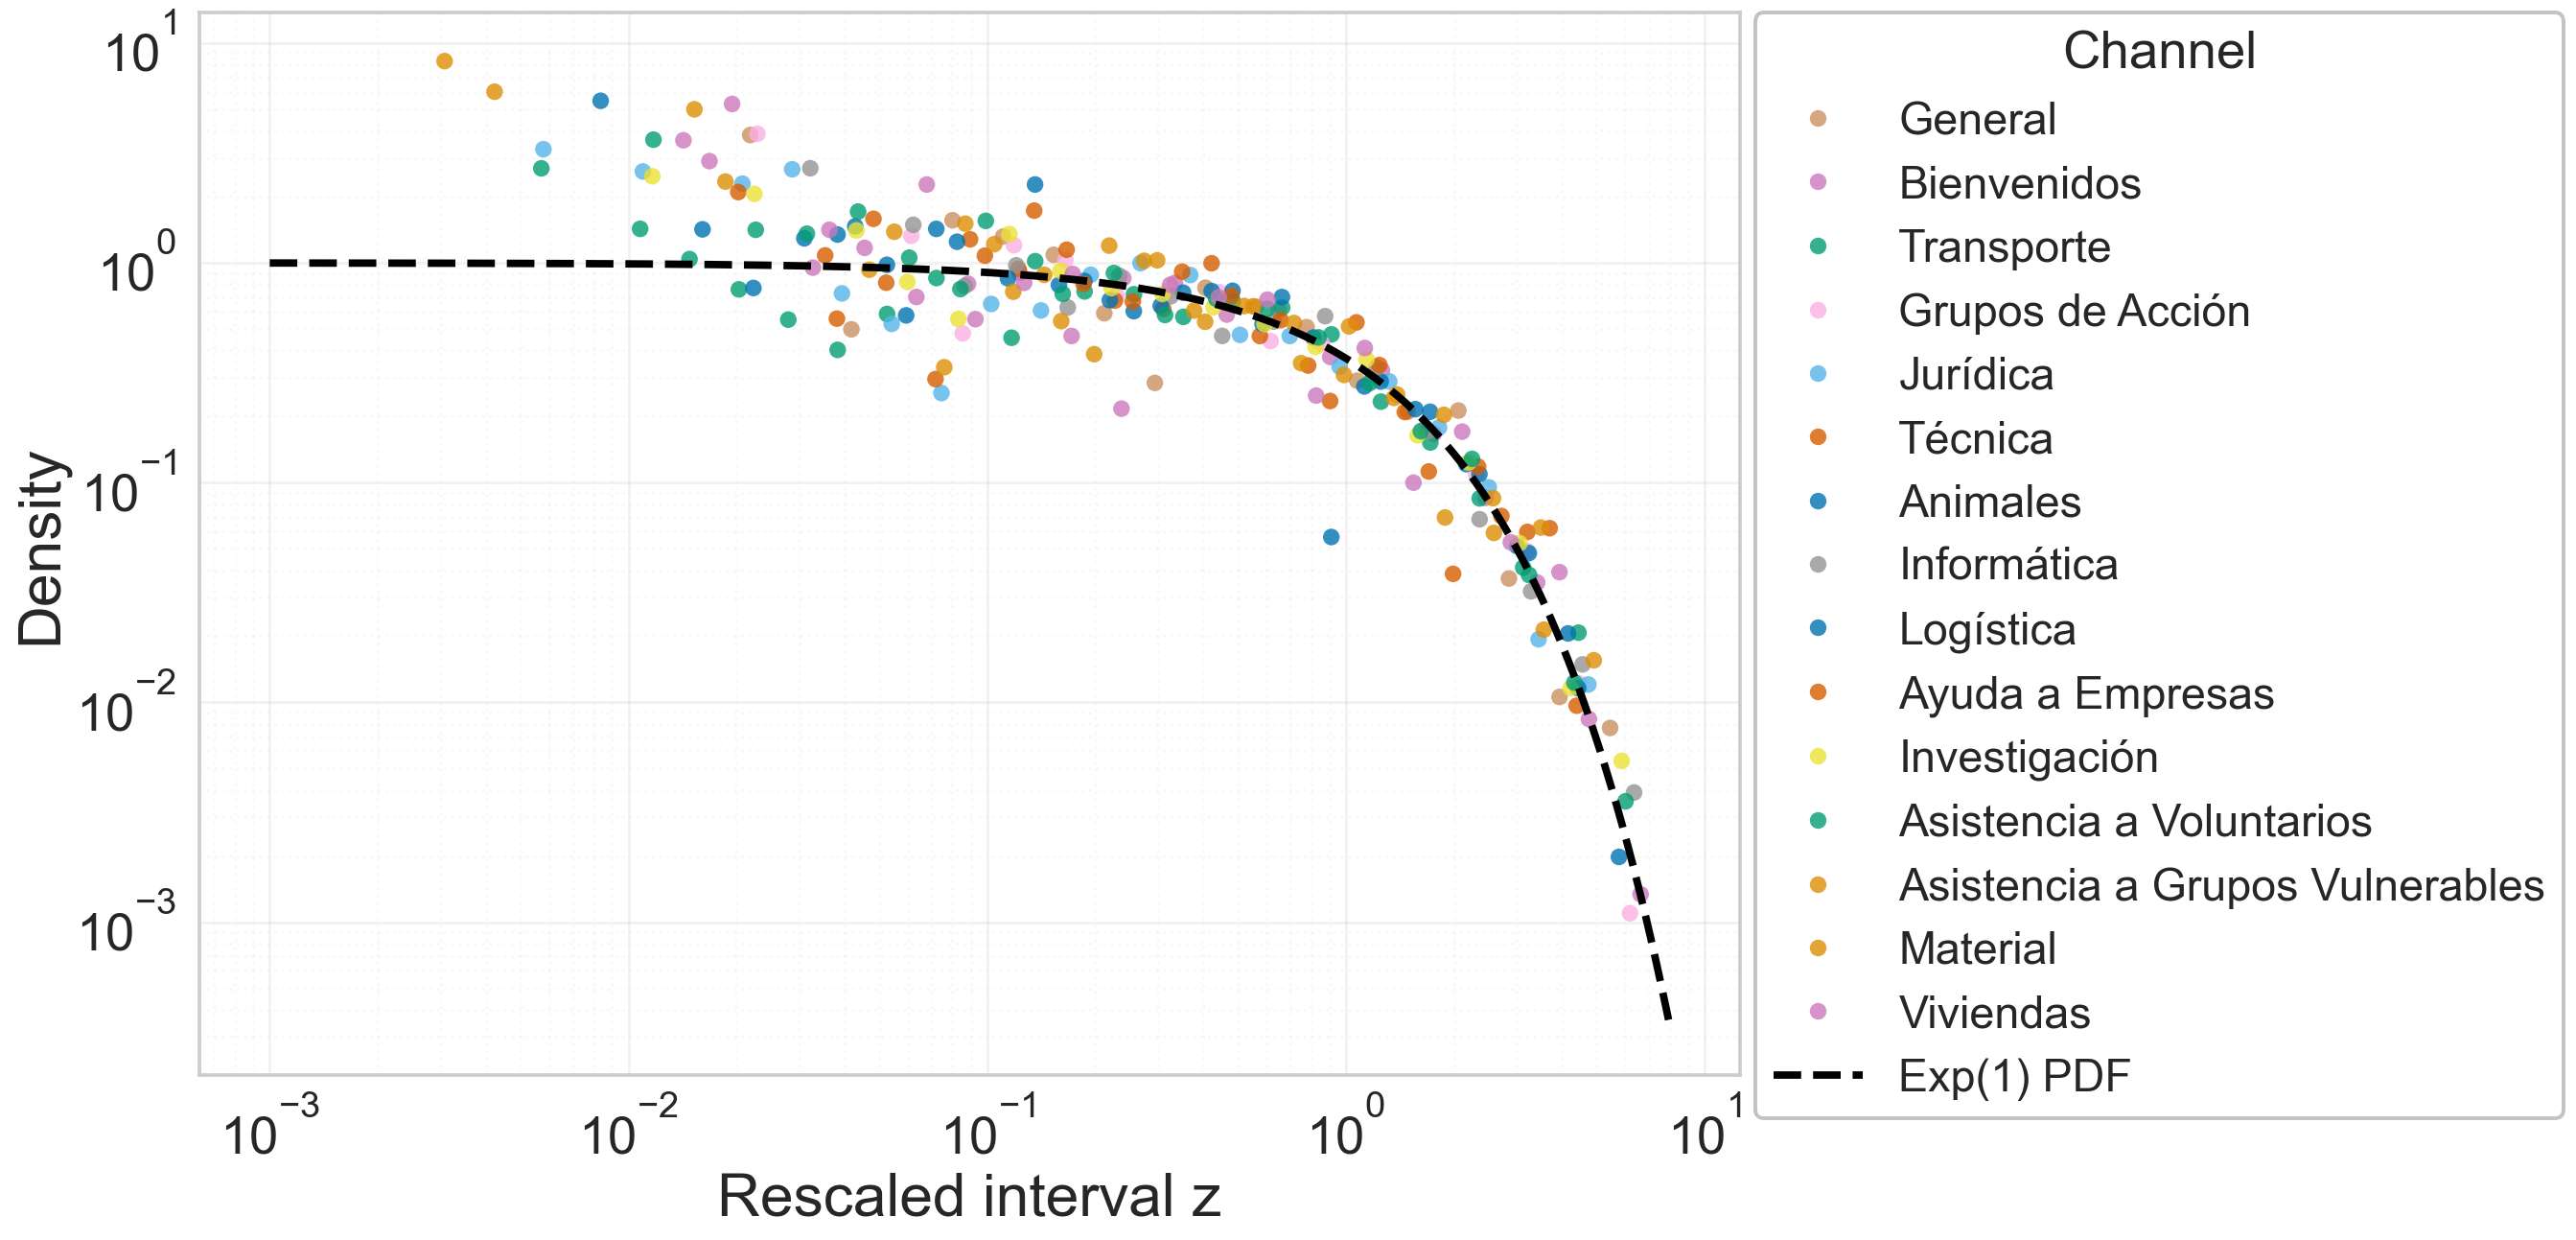

In [22]:
# Poster-ready version of the multi-channel rescaled-interval log-log point plot
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

if 'rescaling_results' not in globals() or len(rescaling_results) == 0:
    raise ValueError("`rescaling_results` not found. Run the previous rescaling cell first.")

# Build plotting dataframe from log-binned densities per channel
records = []
for channel, out in rescaling_results.items():
    z_channel = np.asarray(out["z"], dtype=float)
    z_channel = z_channel[np.isfinite(z_channel)]
    z_channel = z_channel[z_channel > 0]

    if z_channel.size < 30:
        continue

    z_min = max(np.min(z_channel), 1e-3)
    z_max = np.max(z_channel)
    if z_max <= z_min:
        continue

    bins = np.logspace(np.log10(z_min), np.log10(z_max), 28)
    hist, edges = np.histogram(z_channel, bins=bins, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])
    mask = hist > 0

    for c, h in zip(centers[mask], hist[mask]):
        records.append({"channel": channel, "z": c, "density": h})

plot_df = pd.DataFrame(records)
if plot_df.empty:
    raise ValueError("No valid binned points were generated for plotting.")

# Styling tuned for scientific posters
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.titlesize": 36,
    "axes.labelsize": 32,
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
    "legend.fontsize": 24,
    "legend.title_fontsize": 28,
    "font.size": 32,
})

fig, ax = plt.subplots(figsize=(20, 10))

channels = sorted(plot_df["channel"].unique())
palette = sns.color_palette("colorblind", n_colors=max(len(channels), 3))
palette_map = {ch: palette[i % len(palette)] for i, ch in enumerate(channels)}

sns.scatterplot(
    data=plot_df,
    x="z",
    y="density",
    hue="channel",
    palette=palette_map,
    s=80,
    alpha=0.8,
    linewidth=0,
    ax=ax,
    legend=True,
 )

# Theoretical Exp(1) PDF overlay
xmax = max(8, float(plot_df["z"].max()) * 1.15)
x = np.logspace(-3, np.log10(xmax), 500)
ax.plot(x, stats.expon.pdf(x, scale=1), color="black", linestyle="--", linewidth=4, label="Exp(1) PDF")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rescaled interval z")
ax.set_ylabel("Density")
#ax.set_title("Rescaled Intervals by Channel vs Exp(1)", pad=18, weight="bold")

ax.grid(which="major", linestyle="-", alpha=0.25)
ax.grid(which="minor", linestyle=":", alpha=0.12)

# Compact legend outside the axes
handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(
    handles, labels,
    title="Channel",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0,
    frameon=True,
    ncol=1,
 )
legend.get_frame().set_edgecolor("0.75")
legend.get_frame().set_linewidth(2)
legend.get_frame().set_alpha(0.95)

plt.tight_layout()
plt.show()

# Optional poster export
# fig.savefig("rescaled_intervals_poster_ready.png", bbox_inches="tight")

### Time-Rescaling Theorem by Channel with data over 1000 messages

In [24]:
# Obtain the truncated power law fit for the waiting times of the different channels
# Keep the same threshold used in the next cell
min_messages = 1000

# Map display labels to exact topic names in the dataset
channel_topic_names = {
    'General': 'Discusión general',
    'Bienvenidos': 'Bienvenid@s a la Red de Voluntari@s (leed primero)',
    'Transporte': 'Transporte de personas a Comunidad Valenciana',
    'Grupos de Acción': 'Grupos de Acción Voluntarios en Terreno',
    'Jurídica': 'Asistencia Jurídica/Seguros',
    'Técnica': 'Asistencia Técnica y Maquinaria (mecánica, fontanería, electricidad, agricola)',
    'Animales': 'Asistencia animales compañia y otros',
    'Informática': 'Asistencia Informática/Soporte EAT',
    'Logística': 'Logística Interna Valencia(puntos de recepción)',
    'Ayuda a Empresas': 'Ayuda de Empresas',
    'Investigación': 'Investigación Ciudadana: Responsabilidades Políticas',
    'Asistencia a Voluntarios': 'Asistencia a Voluntarios (Comida y Acogida))',
    'Asistencia a Grupos Vulnerables': 'Asis. Grupos Vulnerables (Maternidad , Infancia, Mayores, etc)',
    'Material': 'Material Video/Fotográfico',
    'Webs': 'Webs Esenciales',
    'Mensajes de Ayuda': 'Mensajes de Ayuda (Ofrezco/Necesito)',
    'Voluntarios de Fuera': 'Voluntarios de fuera de Valencia (Madrid, Cataluña, Alicante, Castellón)',
    'Viviendas': 'Viviendas Edificación , Muebles y Acondicionamiento'
}

# True message counts per channel (criterion requested by section title)
channel_message_counts = df_2024['topic_name'].value_counts().to_dict()

poll_waiting_times = {
    'General': waiting_times_general,
    'Bienvenidos': waiting_times_bienvenidos,
    'Transporte': waiting_times_tranporte,
    'Grupos de Acción': waiting_times_grupos_accion,
    'Jurídica': waiting_times_juridica,
    'Técnica': waiting_times_tecnica,
    'Animales': waiting_times_animales,
    'Informática': waiting_times_informatica,
    'Logística': waiting_times_logistica,
    'Ayuda a Empresas': waiting_times_ayudaempresas,
    'Investigación': waiting_times_investigacion,
    'Asistencia a Voluntarios': waiting_times_asistencia_voluntarios,
    'Asistencia a Grupos Vulnerables': waiting_times_asistencia_vulnerables,
    'Material': waiting_times_material,
    'Webs': waiting_times_webs,
    'Mensajes de Ayuda': waiting_times_mensajes_ayuda,
    'Voluntarios de Fuera': waiting_times_voluntarios_fuera,
    'Viviendas': waiting_times_viviendas
}

results = {}
for channel, waits in poll_waiting_times.items():
    topic_name = channel_topic_names[channel]
    raw_messages = int(channel_message_counts.get(topic_name, 0))
    if raw_messages < min_messages:
        print(f"Skipping {channel} (messages={raw_messages}, requires >= {min_messages})")
        continue

    data = np.asarray(waits.values, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]

    if len(data) < 30:
        print(f"Skipping {channel} (not enough positive waiting times: n={len(data)})")
        continue

    fit = powerlaw.Fit(data, discrete=False, verbose=False)
    tpl = fit.truncated_power_law
    results[channel] = {
        'alpha': getattr(tpl, "alpha", np.nan),
        'lambda': getattr(tpl, "Lambda", np.nan),
        'xmin': getattr(tpl, "xmin", np.nan),
        'sigma': getattr(tpl, "sigma", np.nan),
        'n_tail': int(np.sum(data >= getattr(tpl, "xmin", np.nan))),
        'n_total': len(data),
        'n_messages': raw_messages
    }
    print(f"Finished fitting {channel} (messages={raw_messages}, positive_waits={len(data)})")
    print(f"  alpha: {results[channel]['alpha']:.4f}, lambda: {results[channel]['lambda']:.6f}, xmin: {results[channel]['xmin']:.4f}, sigma: {results[channel]['sigma']:.4f}")





Skipping General (messages=256, requires >= 1000)
Finished fitting Bienvenidos (messages=2695, positive_waits=2615)
  alpha: 2.0788, lambda: 0.000015, xmin: 72.0000, sigma: nan
Finished fitting Transporte (messages=2058, positive_waits=1974)
  alpha: 1.9051, lambda: 0.000009, xmin: 541.0000, sigma: nan
Finished fitting Grupos de Acción (messages=1000, positive_waits=926)
  alpha: 1.8179, lambda: 0.000244, xmin: 32.0000, sigma: nan
Skipping Jurídica (messages=754, requires >= 1000)
Skipping Técnica (messages=477, requires >= 1000)
Finished fitting Animales (messages=1006, positive_waits=874)
  alpha: 1.9231, lambda: 0.000036, xmin: 1114.0000, sigma: nan


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

Finished fitting Informática (messages=1960, positive_waits=1914)
  alpha: 2.1893, lambda: 0.000000, xmin: 42.0000, sigma: nan
Finished fitting Logística (messages=1231, positive_waits=1188)
  alpha: 1.5041, lambda: 0.000035, xmin: 64.0000, sigma: nan
Skipping Ayuda a Empresas (messages=268, requires >= 1000)
Finished fitting Investigación (messages=2709, positive_waits=2625)
  alpha: 1.6858, lambda: 0.000034, xmin: 54.0000, sigma: nan
Finished fitting Asistencia a Voluntarios (messages=1163, positive_waits=1128)
  alpha: 1.8890, lambda: 0.000039, xmin: 89.0000, sigma: nan
Skipping Asistencia a Grupos Vulnerables (messages=144, requires >= 1000)
Finished fitting Material (messages=1030, positive_waits=881)
  alpha: 1.8225, lambda: 0.000020, xmin: 1040.0000, sigma: nan
Skipping Webs (messages=12, requires >= 1000)
Skipping Mensajes de Ayuda (messages=3, requires >= 1000)
Skipping Voluntarios de Fuera (messages=4, requires >= 1000)
Skipping Viviendas (messages=274, requires >= 1000)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

Skipping General: messages=256 (< 1000)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

Skipping Jurídica: messages=754 (< 1000)
Skipping Técnica: messages=477 (< 1000)
Skipping Ayuda a Empresas: messages=268 (< 1000)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

Skipping Asistencia a Grupos Vulnerables: messages=144 (< 1000)
Skipping Webs: messages=12 (< 1000)
Skipping Mensajes de Ayuda: messages=3 (< 1000)
Skipping Voluntarios de Fuera: messages=4 (< 1000)
Skipping Viviendas: messages=274 (< 1000)
Time-rescaling summary (higher p and lower KS are better):


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


,channel,n_messages,n_positive_waits,n_tail,alpha,lambda,xmin,"KS_U(0,1)","p_U(0,1)",KS_Exp(1),p_Exp(1)
0,Material,1030,881,123,1.822508,2.029301e-05,1040.0,0.038413,0.990310,0.038413,0.990310
1,Asistencia a Voluntarios,1163,1128,287,1.888996,3.905965e-05,89.0,0.027367,0.978660,0.027367,0.978660
2,Bienvenidos,2695,2615,690,2.078786,1.462642e-05,72.0,0.022834,0.856229,0.022834,0.856229
3,Logística,1231,1188,538,1.504092,3.523030e-05,64.0,0.027144,0.812438,0.027144,0.812438
4,Investigación,2709,2625,1063,1.685818,3.406476e-05,54.0,0.019383,0.811874,0.019383,0.811874
5,Grupos de Acción,1000,926,457,1.817940,2.443061e-04,32.0,0.029868,0.798042,0.029868,0.798042
6,Animales,1006,874,62,1.923059,3.622103e-05,1114.0,0.080497,0.786536,0.080497,0.786536
7,Transporte,2058,1974,205,1.905059,8.964089e-06,541.0,0.051881,0.620238,0.051881,0.620238
8,Informática,1960,1914,500,2.189323,8.342574e-11,42.0,0.035453,0.544019,0.035453,0.544019


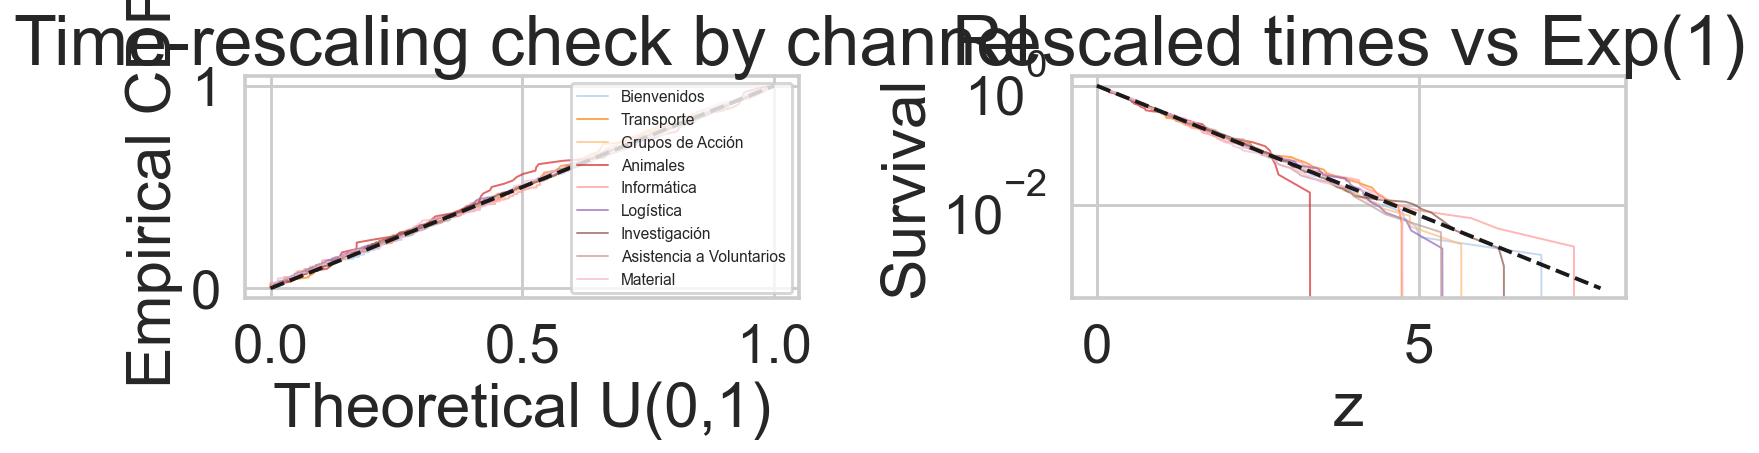

In [25]:
# Apply Time Rescaling Theorem to the waiting times of the different channels
from scipy.stats import kstest

# Minimum sample size for this section (based on true message counts)
min_messages = 1000

# Fallback if the previous cell was not executed in this kernel
if 'channel_message_counts' not in globals():
    channel_message_counts = df_2024['topic_name'].value_counts().to_dict()
if 'channel_topic_names' not in globals():
    channel_topic_names = {
        'General': 'Discusión general',
        'Bienvenidos': 'Bienvenid@s a la Red de Voluntari@s (leed primero)',
        'Transporte': 'Transporte de personas a Comunidad Valenciana',
        'Grupos de Acción': 'Grupos de Acción Voluntarios en Terreno',
        'Jurídica': 'Asistencia Jurídica/Seguros',
        'Técnica': 'Asistencia Técnica y Maquinaria (mecánica, fontanería, electricidad, agricola)',
        'Animales': 'Asistencia animales compañia y otros',
        'Informática': 'Asistencia Informática/Soporte EAT',
        'Logística': 'Logística Interna Valencia(puntos de recepción)',
        'Ayuda a Empresas': 'Ayuda de Empresas',
        'Investigación': 'Investigación Ciudadana: Responsabilidades Políticas',
        'Asistencia a Voluntarios': 'Asistencia a Voluntarios (Comida y Acogida))',
        'Asistencia a Grupos Vulnerables': 'Asis. Grupos Vulnerables (Maternidad , Infancia, Mayores, etc)',
        'Material': 'Material Video/Fotográfico',
        'Webs': 'Webs Esenciales',
        'Mensajes de Ayuda': 'Mensajes de Ayuda (Ofrezco/Necesito)',
        'Voluntarios de Fuera': 'Voluntarios de fuera de Valencia (Madrid, Cataluña, Alicante, Castellón)',
        'Viviendas': 'Viviendas Edificación , Muebles y Acondicionamiento'
    }

# Containers
rescaling_results = {}
rescaling_summary_rows = []

for channel, waits in poll_waiting_times.items():
    topic_name = channel_topic_names[channel]
    raw_messages = int(channel_message_counts.get(topic_name, 0))
    if raw_messages < min_messages:
        print(f"Skipping {channel}: messages={raw_messages} (< {min_messages})")
        continue

    tau = np.asarray(waits.values, dtype=float)
    tau = tau[np.isfinite(tau)]
    tau = tau[tau > 0]

    if tau.size < 30:
        print(f"Skipping {channel}: not enough positive waiting times (n={tau.size})")
        continue

    # Fit TPL for this channel (same model used in previous cells)
    fit_ch = powerlaw.Fit(tau, discrete=False, verbose=False)
    tpl_ch = fit_ch.truncated_power_law
    xmin_ch = float(getattr(tpl_ch, "xmin", np.nan))

    # The theorem check is applied on the fitted tail
    tau_tail = tau[tau >= xmin_ch]
    if tau_tail.size < 30:
        print(f"Skipping {channel}: not enough tail data (n_tail={tau_tail.size})")
        continue

    # Probability integral transform: U = F(tau) should be Uniform(0,1)
    # Then z = -log(1-U) should be Exp(1)
    u = np.asarray(tpl_ch.cdf(tau_tail), dtype=float)
    u = np.clip(u, 1e-12, 1 - 1e-12)
    z = -np.log(1.0 - u)

    ks_stat_u, ks_p_u = kstest(u, "uniform")
    ks_stat_z, ks_p_z = kstest(z, "expon")

    rescaling_results[channel] = {
        "u": u,
        "z": z,
        "ks_stat_uniform": float(ks_stat_u),
        "ks_p_uniform": float(ks_p_u),
        "ks_stat_exp1": float(ks_stat_z),
        "ks_p_exp1": float(ks_p_z),
        "n_messages": raw_messages,
        "n_positive_waits": int(tau.size),
        "n_tail": int(tau_tail.size),
        "alpha": float(getattr(tpl_ch, "alpha", np.nan)),
        "lambda": float(getattr(tpl_ch, "Lambda", np.nan)),
        "xmin": xmin_ch,
    }

    rescaling_summary_rows.append(
        {
            "channel": channel,
            "n_messages": raw_messages,
            "n_positive_waits": int(tau.size),
            "n_tail": int(tau_tail.size),
            "alpha": float(getattr(tpl_ch, "alpha", np.nan)),
            "lambda": float(getattr(tpl_ch, "Lambda", np.nan)),
            "xmin": xmin_ch,
            "KS_U(0,1)": float(ks_stat_u),
            "p_U(0,1)": float(ks_p_u),
            "KS_Exp(1)": float(ks_stat_z),
            "p_Exp(1)": float(ks_p_z),
        }
    )

# Summary table (safe even if empty)
rescaling_summary = pd.DataFrame(rescaling_summary_rows)
if not rescaling_summary.empty:
    rescaling_summary = rescaling_summary.sort_values(
        ["p_U(0,1)", "KS_U(0,1)"], ascending=[False, True]
    ).reset_index(drop=True)

print("Time-rescaling summary (higher p and lower KS are better):")
display(rescaling_summary)

# Optional pooled diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for channel, out in rescaling_results.items():
    u_sorted = np.sort(out["u"])
    ecdf = np.arange(1, len(u_sorted) + 1) / len(u_sorted)
    axes[0].plot(u_sorted, ecdf, lw=1, alpha=0.7, label=channel, color=channel_colors[channel])

axes[0].plot([0, 1], [0, 1], "k--", lw=2)
axes[0].set_xlabel("Theoretical U(0,1)")
axes[0].set_ylabel("Empirical CDF")
axes[0].set_title("Time-rescaling check by channel")

for channel, out in rescaling_results.items():
    z_sorted = np.sort(out["z"])
    surv = 1.0 - np.arange(1, len(z_sorted) + 1) / len(z_sorted)
    axes[1].plot(z_sorted, surv, lw=1, alpha=0.7, label=channel, color=channel_colors[channel])

z_max = max([np.max(v["z"]) for v in rescaling_results.values()], default=8)
z_grid = np.linspace(0, z_max, 200)
axes[1].plot(z_grid, np.exp(-z_grid), "k--", lw=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("z")
axes[1].set_ylabel("Survival")
axes[1].set_title("Rescaled times vs Exp(1)")

if 0 < len(rescaling_results) <= 10:
    axes[0].legend(fontsize=8)
elif len(rescaling_results) > 10:
    axes[0].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

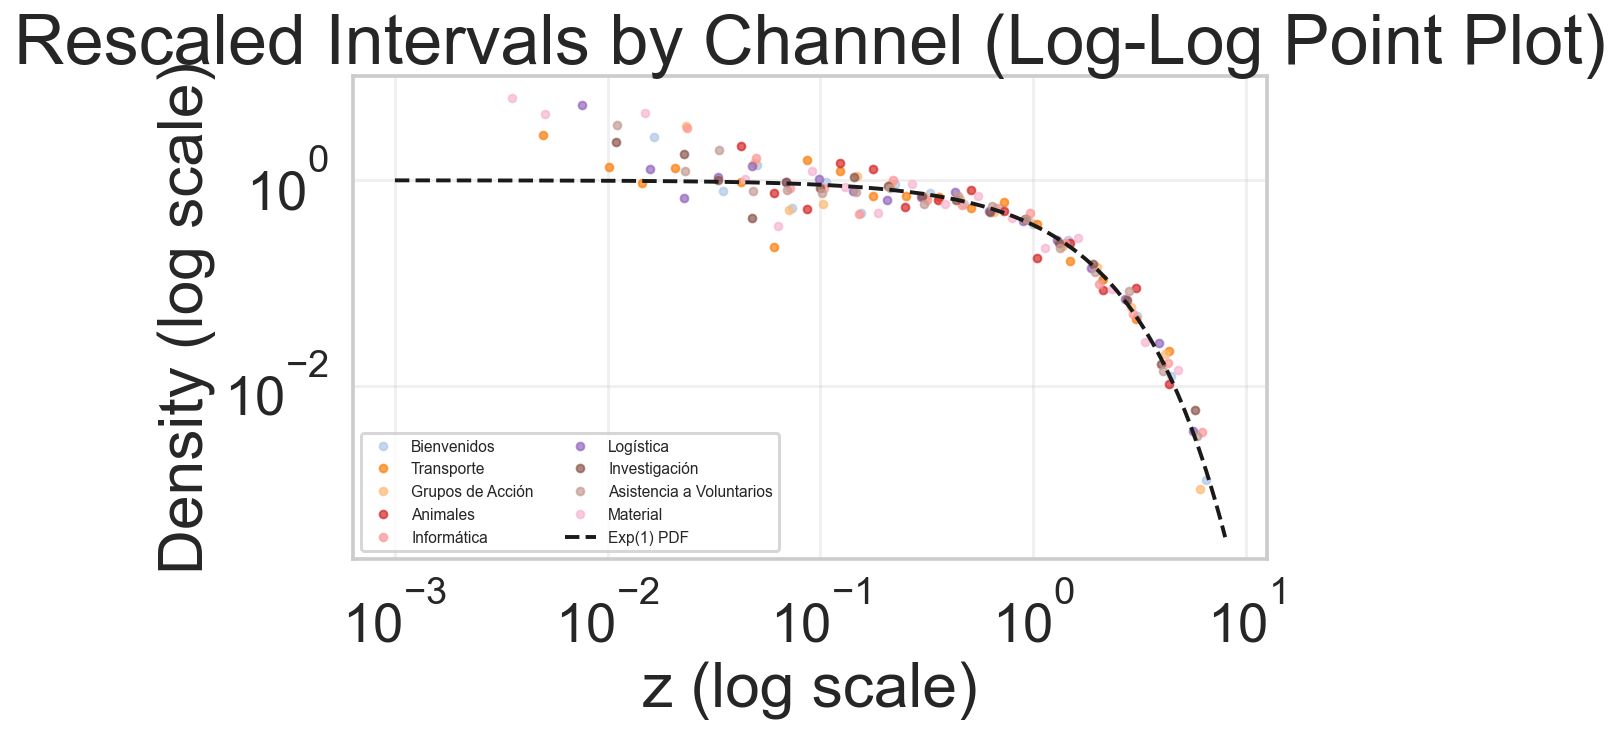

In [26]:
# Multi-channel version of the log-log rescaled-interval plot (point plot)
# Requires `rescaling_results` from the previous cell

if not rescaling_results:
    print("No channels available to plot. Run Cell 31 first and check filtering conditions.")
else:
    plt.figure(figsize=(9, 6))
    plotted_channels = 0

    for channel, out in rescaling_results.items():
        z_channel = np.asarray(out["z"], dtype=float)
        z_channel = z_channel[np.isfinite(z_channel)]
        z_channel = z_channel[z_channel > 0]

        if z_channel.size < 30:
            continue

        # Log-binned empirical density (points)
        z_min = max(np.min(z_channel), 1e-3)
        z_max = np.max(z_channel)
        if z_max <= z_min:
            continue

        bins = np.logspace(np.log10(z_min), np.log10(z_max), 25)
        hist, edges = np.histogram(z_channel, bins=bins, density=True)
        centers = np.sqrt(edges[:-1] * edges[1:])

        mask = hist > 0
        if np.any(mask):
            plt.plot(
                centers[mask], hist[mask], marker='o', linestyle='none',
                ms=4, alpha=0.7, label=channel, color=channel_colors[channel]
            )
            plotted_channels += 1

    # Theoretical Exp(1) density
    z_max_candidates = []
    for out in rescaling_results.values():
        z_vals = np.asarray(out["z"], dtype=float)
        z_vals = z_vals[np.isfinite(z_vals)]
        z_vals = z_vals[z_vals > 0]
        if z_vals.size > 0:
            z_max_candidates.append(np.max(z_vals))

    z_max_global = max(8.0, max(z_max_candidates) if z_max_candidates else 8.0)
    x = np.logspace(-3, np.log10(z_max_global), 400)
    plt.plot(x, stats.expon.pdf(x, scale=1), 'k--', lw=2, label='Exp(1) PDF')

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('z (log scale)')
    plt.ylabel('Density (log scale)')
    plt.title('Rescaled Intervals by Channel (Log-Log Point Plot)')
    plt.grid(True, alpha=0.3)

    if plotted_channels > 0:
        plt.legend(fontsize=8, ncol=2)
    else:
        print("No channel had enough valid points to plot after filtering.")

    plt.tight_layout()
    plt.show()

## Rescaling with KM Finite-Size-Bias Correction

Instead of fitting the TPL directly to raw IETs, we now:
1. Compute within-channel IETs properly (not the global `df.diff()`).
2. Add the time from the **last message → observation cutoff** as a **censored** IET — this is the finite-size-bias correction: the channel is still "alive", we just haven't seen its next message yet.
3. Fit the **Kaplan–Meier** survival estimator on these (IETs + censored) observations.
4. Fit a **truncated power law** (TPL) to the normalized KM survival curve via `scipy.optimize.curve_fit`.
5. Apply the **time-rescaling theorem** using this KM-based TPL as the model.

In [27]:

# ── KM finite-size-bias correction: per-channel survival + TPL fit ────────────
from lifelines import KaplanMeierFitter
from scipy.optimize import curve_fit

cutoff_km = df_2024['date'].max()


def channel_iets_and_last(topic_name):
    """Within-channel IETs (seconds) and timestamp of last message."""
    msgs = df_2024[df_2024['topic_name'] == topic_name].sort_values('date')
    ts   = msgs['date'].values
    iets = np.diff(ts).astype('timedelta64[s]').astype(float)
    iets = iets[iets > 0]
    return iets, msgs['date'].iloc[-1]


def km_channel_survival(iets, last_time, cutoff):
    """KM estimator with censored last IET for finite-size-bias correction."""
    last_censored = max((pd.Timestamp(cutoff) - pd.Timestamp(last_time)).total_seconds(), 0.0)
    durations = np.concatenate([iets, [last_censored]])
    events    = np.concatenate([np.ones(len(iets), dtype=bool), [False]])
    kmf = KaplanMeierFitter()
    kmf.fit(durations, event_observed=events)
    km_t = kmf.survival_function_.index.values.astype(float)
    km_s = kmf.survival_function_['KM_estimate'].values.astype(float)
    return km_t, km_s


def fit_tpl_to_km(km_t, km_s, xmin):
    """Fit TPL survival to KM curve, normalized so S(xmin) = 1."""
    mask = (km_t >= xmin) & (km_s > 0)
    if mask.sum() < 5:
        return None, None
    s_at_xmin = float(np.interp(xmin, km_t, km_s))
    if s_at_xmin <= 0:
        return None, None
    t_tail = km_t[mask]
    s_norm = km_s[mask] / s_at_xmin

    def tpl_surv(t, alpha, lam):
        return (t / xmin) ** (-(alpha - 1)) * np.exp(-(t - xmin) * lam)

    try:
        popt, _ = curve_fit(tpl_surv, t_tail, s_norm,
                            p0=[1.5, 1e-6],
                            bounds=([1.001, 0.0], [20.0, np.inf]),
                            maxfev=10_000)
        return popt, t_tail
    except Exception as e:
        print(f"  curve_fit failed: {e}")
        return None, None


# ── Fit all channels with enough data ─────────────────────────────────────────
km_results = {}

for channel, _ in poll_waiting_times.items():
    topic_name   = channel_topic_names[channel]
    raw_messages = int(channel_message_counts.get(topic_name, 0))
    if raw_messages < min_messages:
        continue

    iets, last_time = channel_iets_and_last(topic_name)
    if len(iets) < 30:
        print(f"Skipping {channel}: not enough IETs (n={len(iets)})")
        continue

    km_t, km_s = km_channel_survival(iets, last_time, cutoff_km)

    # xmin from powerlaw on the raw IETs
    fit_raw = powerlaw.Fit(iets, discrete=False, verbose=False)
    xmin    = float(fit_raw.xmin)

    popt, t_tail = fit_tpl_to_km(km_t, km_s, xmin)
    if popt is None:
        print(f"Skipping {channel}: TPL fit on KM curve failed")
        continue

    alpha_km, lam_km = popt
    km_results[channel] = {
        'km_t': km_t, 'km_s': km_s,
        'xmin': xmin, 'alpha': alpha_km, 'lambda': lam_km,
        'iets': iets, 't_tail': t_tail,
        'n_messages': raw_messages, 'n_iets': len(iets),
    }
    print(f"{channel}: α={alpha_km:.3f}, 1/λ={1/lam_km/3600:.1f} h, "
          f"xmin={xmin:.0f} s, n_iets={len(iets)}")


Bienvenidos: α=1.906, 1/λ=14.4 h, xmin=402 s, n_iets=2647
Transporte: α=1.554, 1/λ=10.4 h, xmin=789 s, n_iets=1978
Grupos de Acción: α=2.153, 1/λ=753484279728556672.0 h, xmin=1786 s, n_iets=933
Animales: α=1.732, 1/λ=64.7 h, xmin=2789 s, n_iets=877
Informática: α=1.572, 1/λ=4343795619128323.0 h, xmin=66 s, n_iets=1935
Logística: α=2.407, 1/λ=286.5 h, xmin=26201 s, n_iets=1193
Investigación: α=1.671, 1/λ=78.6 h, xmin=1208 s, n_iets=2647
Asistencia a Voluntarios: α=1.875, 1/λ=8029854208019331547136.0 h, xmin=919 s, n_iets=1135
Material: α=1.642, 1/λ=40.4 h, xmin=2954 s, n_iets=881


In [28]:

# ── Time-rescaling using KM-fitted TPL ────────────────────────────────────────
from scipy.stats import kstest

km_rescaling_results = {}
km_rescaling_rows    = []

for channel, res in km_results.items():
    iets  = res['iets']
    xmin  = res['xmin']
    alpha = res['alpha']
    lam   = res['lambda']

    tail = iets[iets >= xmin]
    if len(tail) < 30:
        print(f"Skipping {channel}: not enough tail IETs (n={len(tail)})")
        continue

    # Conditional survival on the tail (normalized at xmin = 1 by construction)
    s_vals = (tail / xmin) ** (-(alpha - 1)) * np.exp(-(tail - xmin) * lam)
    s_vals = np.clip(s_vals, 0.0, 1.0)
    u = np.clip(1.0 - s_vals, 1e-12, 1 - 1e-12)
    z = -np.log(1.0 - u)

    ks_stat_u, ks_p_u = kstest(u, 'uniform')
    ks_stat_z, ks_p_z = kstest(z, 'expon')

    km_rescaling_results[channel] = {
        'u': u, 'z': z,
        'ks_stat_uniform': ks_stat_u, 'ks_p_uniform': ks_p_u,
        'ks_stat_exp1':    ks_stat_z, 'ks_p_exp1':    ks_p_z,
        'n_tail': len(tail),
    }
    km_rescaling_rows.append({
        'channel':    channel,
        'n_messages': res['n_messages'],
        'n_tail':     len(tail),
        'alpha':      alpha,
        'lambda':     lam,
        'xmin':       xmin,
        'KS_U(0,1)':  ks_stat_u,  'p_U(0,1)': ks_p_u,
        'KS_Exp(1)':  ks_stat_z,  'p_Exp(1)': ks_p_z,
    })

km_rescaling_summary = pd.DataFrame(km_rescaling_rows)
if not km_rescaling_summary.empty:
    km_rescaling_summary = km_rescaling_summary.sort_values(
        ['p_U(0,1)', 'KS_U(0,1)'], ascending=[False, True]
    ).reset_index(drop=True)

print("KM-corrected time-rescaling summary (higher p / lower KS = better fit):")
display(km_rescaling_summary)


KM-corrected time-rescaling summary (higher p / lower KS = better fit):


,channel,n_messages,n_tail,alpha,lambda,xmin,"KS_U(0,1)","p_U(0,1)",KS_Exp(1),p_Exp(1)
0,Logística,1231,53,2.407358,9.695899e-07,26201.0,0.052398,0.997053,0.052398,0.997053
1,Animales,1006,195,1.732143,4.290837e-06,2789.0,0.031242,0.988191,0.031242,0.988191
2,Grupos de Acción,1000,150,2.152580,3.686577e-22,1786.0,0.037946,0.976571,0.037946,0.976571
3,Bienvenidos,2695,508,1.905757,1.927979e-05,402.0,0.022066,0.961003,0.022066,0.961003
4,Asistencia a Voluntarios,1163,244,1.875290,3.459313e-26,919.0,0.033160,0.943052,0.033160,0.943052
5,Transporte,2058,518,1.554418,2.681793e-05,789.0,0.025877,0.869434,0.025877,0.869434
6,Informática,1960,713,1.571622,6.394817e-20,66.0,0.022146,0.867644,0.022146,0.867644
7,Investigación,2709,378,1.671151,3.533721e-06,1208.0,0.030932,0.851202,0.030932,0.851202
8,Material,1030,213,1.641960,6.870964e-06,2954.0,0.047150,0.712621,0.047150,0.712621


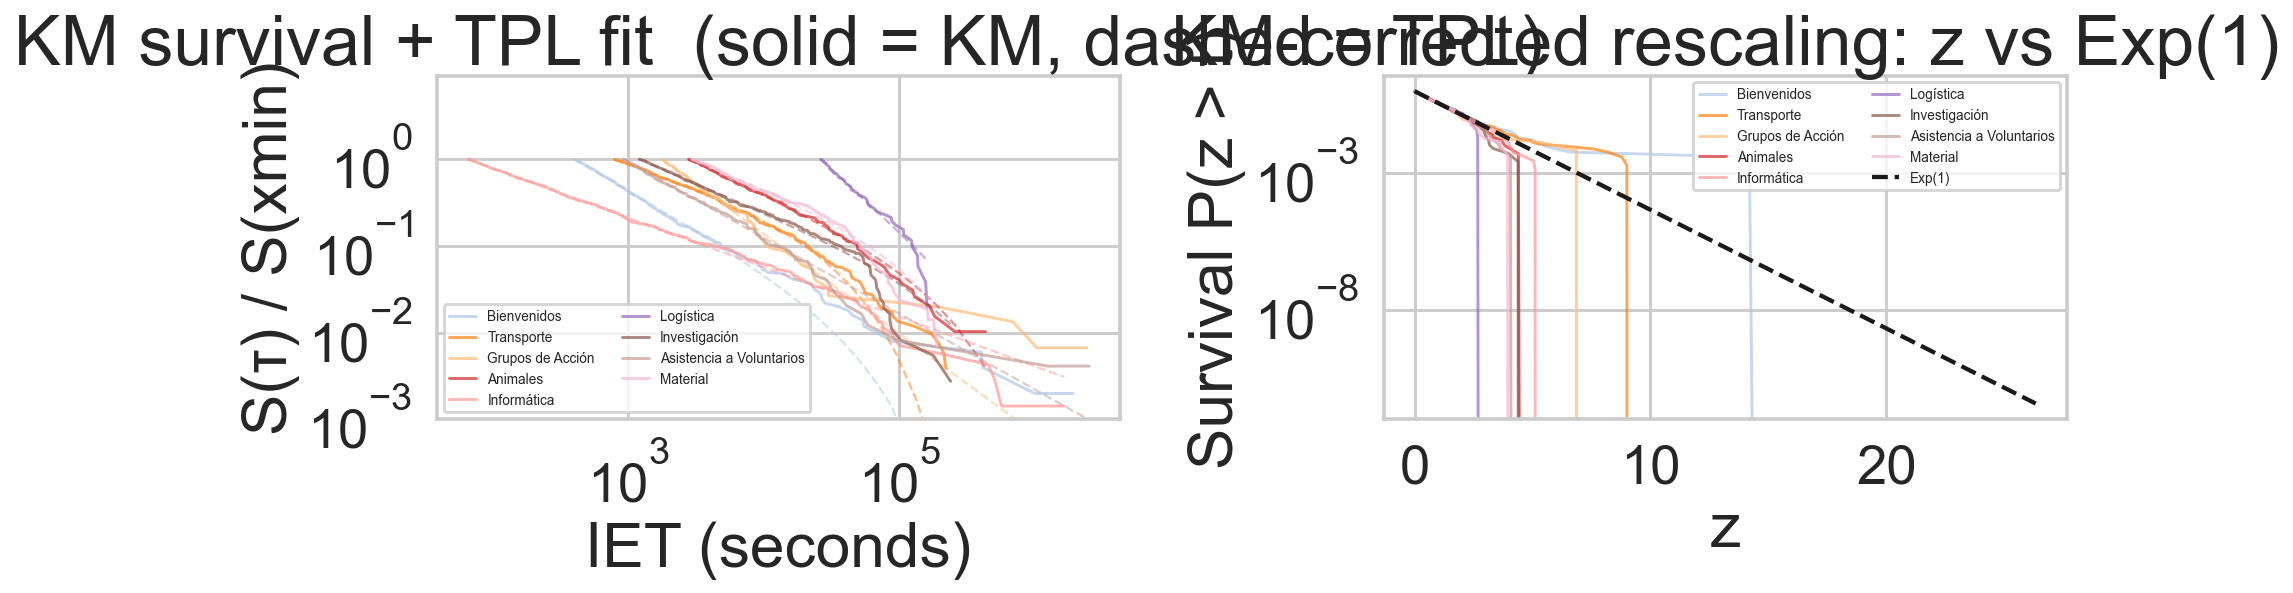

In [29]:

# ── Visualisation: KM survival + TPL fits & rescaled intervals vs Exp(1) ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for channel, res in km_results.items():
    km_t = res['km_t']
    km_s = res['km_s']
    xmin = res['xmin']
    alpha = res['alpha']
    lam   = res['lambda']

    mask_km = (km_t >= xmin) & (km_s > 0)
    s_at_xmin = float(np.interp(xmin, km_t, km_s))
    if s_at_xmin <= 0:
        continue
    axes[0].plot(km_t[mask_km], km_s[mask_km] / s_at_xmin,
                 lw=1.5, alpha=0.7, color=channel_colors[channel], label=channel)

    t_fit = res['t_tail']
    s_fit = (t_fit / xmin) ** (-(alpha - 1)) * np.exp(-(t_fit - xmin) * lam)
    axes[0].plot(t_fit, s_fit,
                 lw=1.2, alpha=0.5, linestyle='--', color=channel_colors[channel])

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_ylim(bottom=1e-3)
axes[0].set_xlabel('IET (seconds)')
axes[0].set_ylabel('S(τ) / S(xmin)')
axes[0].set_title('KM survival + TPL fit  (solid = KM, dashed = TPL)')
axes[0].legend(fontsize=7, ncol=2)

for channel, out in km_rescaling_results.items():
    z_sorted = np.sort(out['z'])
    surv = 1 - np.arange(1, len(z_sorted) + 1) / len(z_sorted)
    axes[1].plot(z_sorted, surv, lw=1.5, alpha=0.7,
                 color=channel_colors[channel], label=channel)

z_max  = max((np.max(v['z']) for v in km_rescaling_results.values()), default=8)
z_grid = np.linspace(0, z_max, 300)
axes[1].plot(z_grid, np.exp(-z_grid), 'k--', lw=2.2, label='Exp(1)')
axes[1].set_yscale('log')
axes[1].set_xlabel('z')
axes[1].set_ylabel('Survival P(z > t)')
axes[1].set_title('KM-corrected rescaling: z vs Exp(1)')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


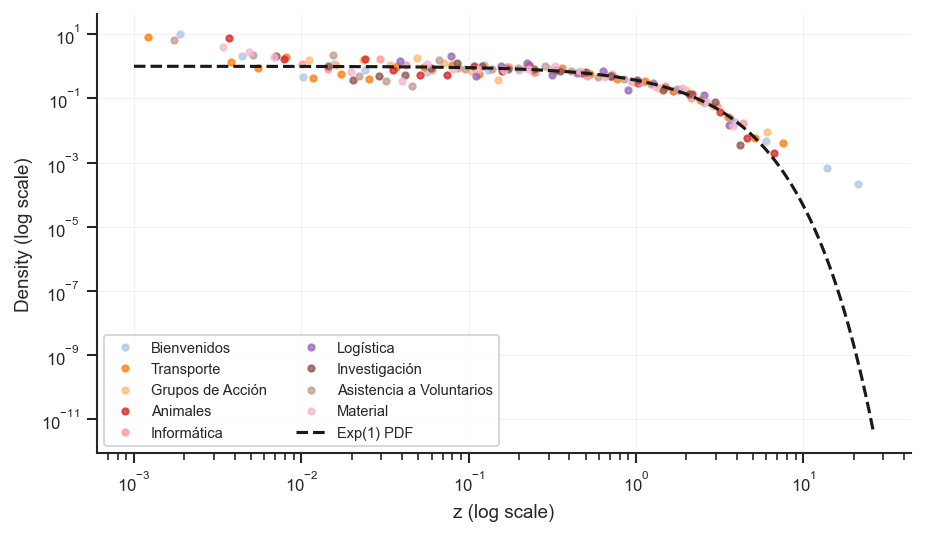

Saved paper_km_rescaled_intervals.pdf


In [31]:
# Paper-ready: KM-corrected rescaled intervals vs Exp(1) PDF (log-log)
import seaborn as sns
import matplotlib as mpl

sns.set_theme(style='ticks', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'legend.fontsize': 7, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
})

fig, ax = plt.subplots(figsize=(7, 3.8))

for channel, out in km_rescaling_results.items():
    z_channel = np.asarray(out['z'], dtype=float)
    z_channel = z_channel[np.isfinite(z_channel) & (z_channel > 0)]
    if z_channel.size < 30:
        continue

    z_min = max(np.min(z_channel), 1e-3)
    z_max = np.max(z_channel)
    if z_max <= z_min:
        continue

    bins    = np.logspace(np.log10(z_min), np.log10(z_max), 25)
    hist, edges = np.histogram(z_channel, bins=bins, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])
    mask    = hist > 0
    ax.plot(centers[mask], hist[mask],
            marker='o', linestyle='none', ms=3, alpha=0.75,
            label=channel, color=channel_colors[channel])

z_max_global = max((np.max(v['z']) for v in km_rescaling_results.values()), default=8)
x = np.logspace(-3, np.log10(max(8, z_max_global)), 400)
ax.plot(x, stats.expon.pdf(x, scale=1), 'k--', lw=1.5, label='Exp(1) PDF')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('z (log scale)')
ax.set_ylabel('Density (log scale)')
ax.grid(True, alpha=0.25, linewidth=0.5)
ax.legend(ncol=2, loc='lower left', framealpha=0.9)

fig.savefig('paper_km_rescaled_intervals.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved paper_km_rescaled_intervals.pdf')


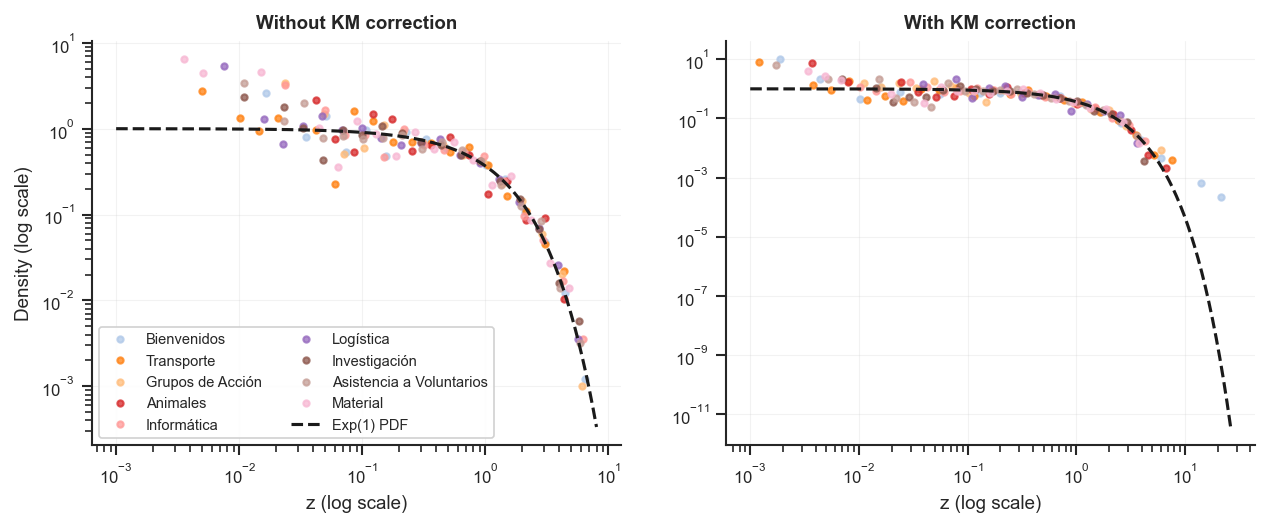

Saved paper_trt_raw_vs_km.pdf


In [33]:
# Paper-ready: raw TPL vs KM-corrected TRT — side by side (log-log)
import seaborn as sns
import matplotlib as mpl

sns.set_theme(style='ticks', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'legend.fontsize': 7, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
})

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

panels = [
    (axes[0], rescaling_results,    'Without KM correction'),
    (axes[1], km_rescaling_results, 'With KM correction'),
]

for ax, results, title in panels:
    z_max_global = 1.0
    for channel, out in results.items():
        z_ch = np.asarray(out['z'], dtype=float)
        z_ch = z_ch[np.isfinite(z_ch) & (z_ch > 0)]
        if z_ch.size < 10:
            continue
        z_min = max(np.min(z_ch), 1e-3)
        z_max = np.max(z_ch)
        if z_max <= z_min:
            continue
        z_max_global = max(z_max_global, z_max)
        bins = np.logspace(np.log10(z_min), np.log10(z_max), 25)
        hist, edges = np.histogram(z_ch, bins=bins, density=True)
        centers = np.sqrt(edges[:-1] * edges[1:])
        mask = hist > 0
        ax.plot(centers[mask], hist[mask],
                marker='o', linestyle='none', ms=3, alpha=0.75,
                label=channel, color=channel_colors[channel])

    x = np.logspace(-3, np.log10(max(8, z_max_global)), 400)
    ax.plot(x, stats.expon.pdf(x, scale=1), 'k--', lw=1.5, label='Exp(1) PDF')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('z (log scale)')
    ax.set_title(title, fontweight='bold', pad=6)
    ax.grid(True, alpha=0.25, linewidth=0.5)
    if ax is axes[0]:
        ax.legend(ncol=2, loc='lower left', framealpha=0.9)

axes[0].set_ylabel('Density (log scale)')

fig.savefig('paper_trt_raw_vs_km.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved paper_trt_raw_vs_km.pdf')
